# Defining Problem Statement

**About Walmart:**

Walmart is an American multinational retail corporation that operates a chain of supercenters, discount departmental stores, and grocery stores from the United States. Walmart has more than 100 million customers worldwide.

**Problem Statement:**

The Management team at Walmart Inc. wants to analyze the customer purchase behavior (specifically, purchase amount) against the customer’s gender and the various other factors to help the business make better decisions. They want to understand if the spending habits differ between male and female customers: Do women spend more on Black Friday than men? (Assume 50 million customers are male and 50 million are female).

# Structure of Dataset

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind,f_oneway
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('walmart_data.csv')
df.head(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
7,1000004,P00346142,M,46-50,7,B,2,1,1,15854
8,1000004,P0097242,M,46-50,7,B,2,1,1,15686
9,1000005,P00274942,M,26-35,20,A,1,1,8,7871


In [ ]:
df.shape

(550068, 10)

In [ ]:
df.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


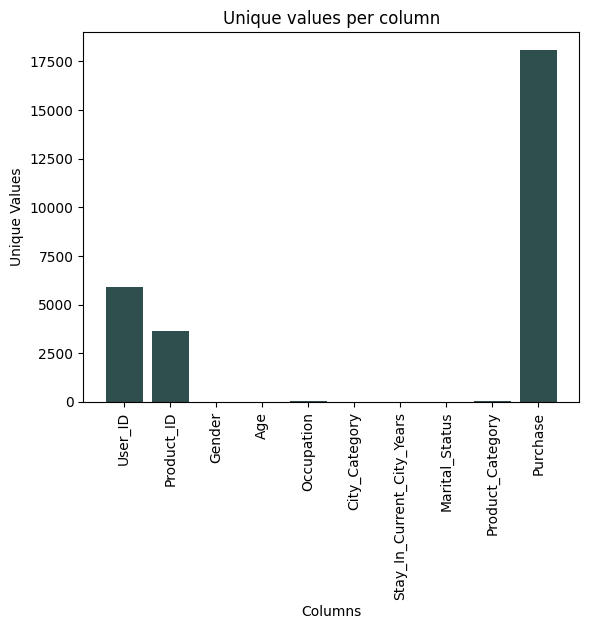

User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category                 20
Purchase                      18105
dtype: int64


In [ ]:
plt.bar(df.nunique().index,df.nunique(),color = 'darkslategray')
plt.xticks(rotation =90)
plt.xlabel('Columns')
plt.ylabel('Unique Values')
plt.title('Unique values per column' )
plt.show()
print(df.nunique())

# Feature Transformation

In [ ]:
# Converting Marital status into their orignal labels for better understanding
df['Marital_Status'] = df['Marital_Status'].apply(lambda x:'Unmarried' if x == 0 else 'Married' )

# coverting datatypes of following columns to avoid aggregation.
df['User_ID']=df['User_ID'].astype('object')
df['Occupation']=df['Occupation'].astype('object')
df['Product_Category']=df['Product_Category'].astype('object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  object
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  object
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  object
 8   Product_Category            550068 non-null  object
 9   Purchase                    550068 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 42.0+ MB


# Missing values and duplicate rows.

In [ ]:
df.isna().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category,0
Purchase,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Statistical Summary.

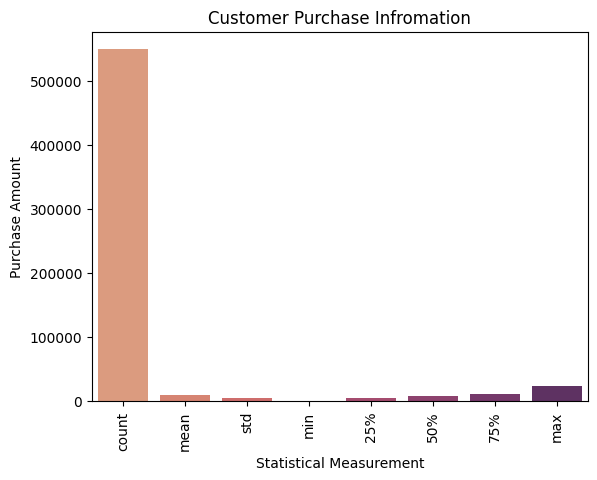

   index       Purchase
0  count  550068.000000
1   mean    9263.968713
2    std    5023.065394
3    min      12.000000
4    25%    5823.000000
5    50%    8047.000000
6    75%   12054.000000
7    max   23961.000000


In [ ]:
stat_data = df.describe().reset_index()
sns.barplot(x = 'index',y = 'Purchase',data = stat_data,palette = 'flare')
plt.xticks(rotation = 90)
plt.xlabel('Statistical Measurement')
plt.ylabel('Purchase Amount')
plt.title('Customer Purchase Infromation')
plt.show()
print(stat_data)


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
User_ID,550068,5891,1001680,1026
Product_ID,550068,3631,P00265242,1880
Gender,550068,2,M,414259
Age,550068,7,26-35,219587
Occupation,550068,21,4,72308
City_Category,550068,3,B,231173
Stay_In_Current_City_Years,550068,5,1,193821
Marital_Status,550068,2,Unmarried,324731
Product_Category,550068,20,5,150933


# Grouping data for each user

**Note:**

In a single day of transactions, a customer generally pays for all purchased  
 products using a single transaction ID. Therefore, grouping the data by  
 customer is effectively the same as grouping it by transaction.

In [ ]:
# grouping dataframe
grouped_df=   df.groupby(['User_ID','Gender','Marital_Status','Age','Occupation','City_Category',
              'Stay_In_Current_City_Years'])['Purchase'].sum().reset_index()

# dropping user_id as each row representing 1 user.
grouped_df.head()

,User_ID,Gender,Marital_Status,Age,Occupation,City_Category,Stay_In_Current_City_Years,Purchase
0,1000001,F,Unmarried,0-17,10,A,2,334093
1,1000002,M,Unmarried,55+,16,C,4+,810472
2,1000003,M,Unmarried,26-35,15,A,3,341635
3,1000004,M,Married,46-50,7,B,2,206468
4,1000005,M,Married,26-35,20,A,1,821001


# Detecting Outliers

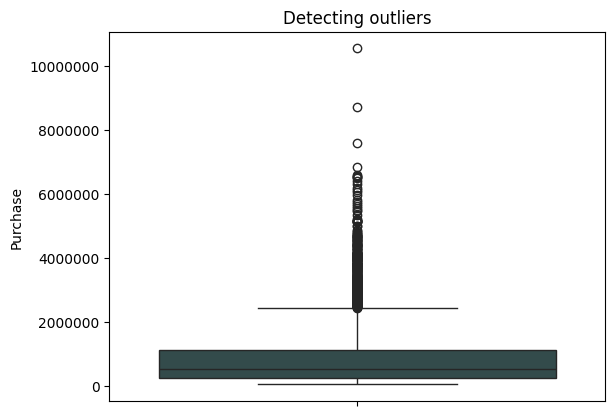

In [ ]:
sns.boxplot(grouped_df['Purchase'], color  = 'darkslategray')
plt.title('Detecting outliers')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()

* Outliers are present on the upper end, indicates that data is right-skewed.




# Percentage of Outliers

In [ ]:
iqr = np.percentile(grouped_df['Purchase'],75)-np.percentile(grouped_df['Purchase'],25)
upper_bound = int(np.percentile(grouped_df['Purchase'],75)+(1.5*iqr))
outliers_percentage= len(grouped_df[grouped_df['Purchase']> upper_bound]['Purchase'])/len(grouped_df['Purchase'])*100
print(f'Percentage of outliers: {outliers_percentage:.2f}')
print('Upper bound:', upper_bound)

Percentage of outliers: 6.94
Upper bound: 2441606


* Purchase Amount contains around 7% outliers.

**Note:**

All the values are non-negative values, indicates valid data where the  
 outliers represents, purchase amount of high-value customers.

In [ ]:
# comparing mean with and without outliers.
print(f'''Mean with outliers: {np.mean(grouped_df['Purchase']):.2f}
Mean without outliers : {np.mean(grouped_df[grouped_df['Purchase']<= upper_bound]['Purchase']):.2f}''')

Mean with outliers: 865016.59
Mean without outliers : 667780.93


* we can notice a significant difference in average purchase amount of outliers  
 and non-outliers data.




# Handling outliers

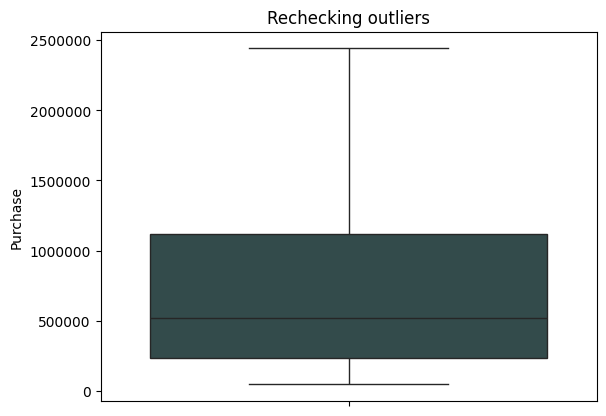

In [ ]:
# clipping  outliers
grouped_df['Purchase'] = np.clip(grouped_df['Purchase'],0,upper_bound)

#rechecking outliers
sns.boxplot(grouped_df['Purchase'], color  = 'darkslategray')
plt.title('Rechecking outliers')
plt.ticklabel_format(style = 'plain', axis = 'y')
plt.show()

# Gender based analysys





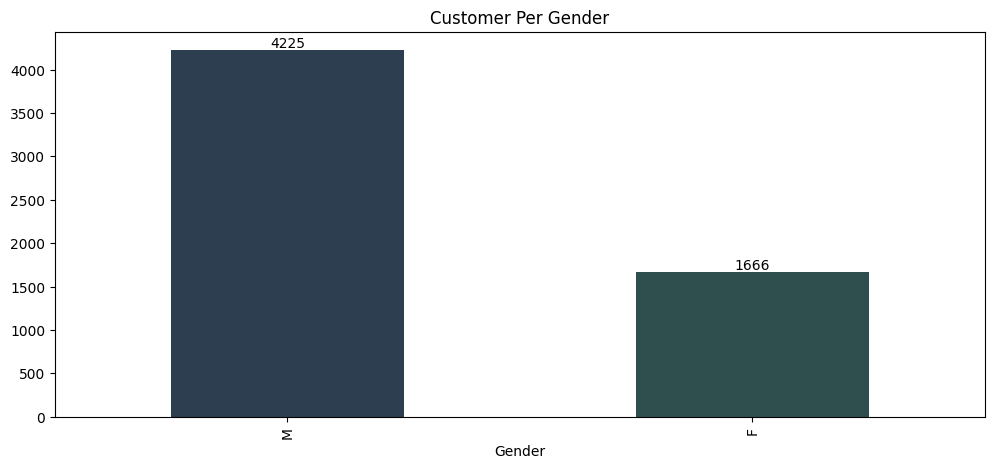

Gender
M    4225
F    1666
Name: count, dtype: int64


In [ ]:
# number of customers
customer_per_gender =grouped_df['Gender'].value_counts()
color = ['#2c3e50','darkslategray']
color2 = ['dimgray','darkslategray']
fig,ax =plt.subplots(figsize = (12,5))
customer_per_gender.plot(kind = 'bar', color = color, ax =ax)
ax.bar_label(ax.containers[0])
ax.set_title('Customer Per Gender')
plt.show()
print(customer_per_gender)

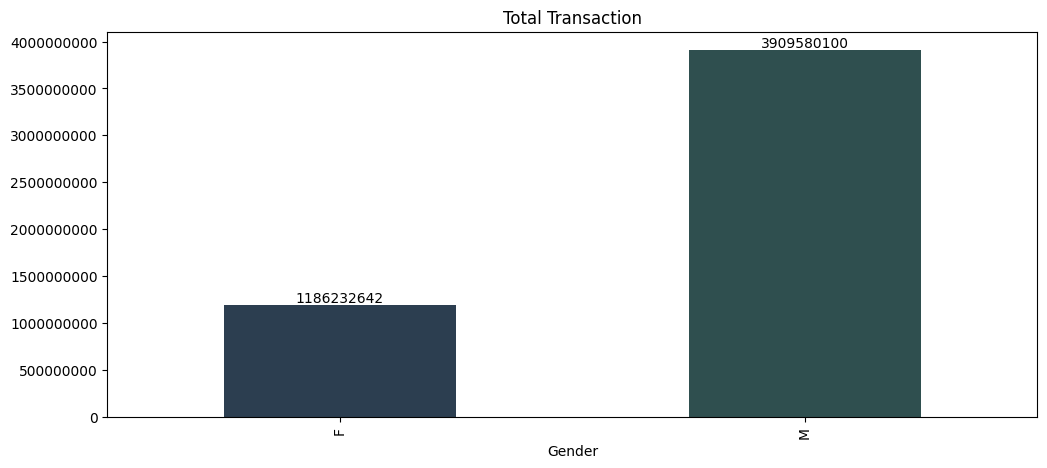

Gender
F    1186232642
M    3909580100
Name: Purchase, dtype: int64


In [ ]:
# Total Transaction
total_transaction_per_gender = df.groupby('Gender')['Purchase'].sum()

fig,ax =plt.subplots(figsize = (12,5))
total_transaction_per_gender.plot(kind = 'bar', color = color, ax =ax)
ax.ticklabel_format(style = 'plain', axis = 'y')
ax.bar_label(ax.containers[0],fmt='%.0f')
ax.set_title('Total Transaction')
plt.show()
print(total_transaction_per_gender)

* 4225 Males shopped during Black Friday, which is significantly greater than  
  1666 Females who shopped during same event.
* Similar kind of difference can be observed in terms of their total     transaction  
 where, Male total transaction is 3.90 Billion while Female total transaction  
  is 1.18 Billion.

# Confidence Interval 1

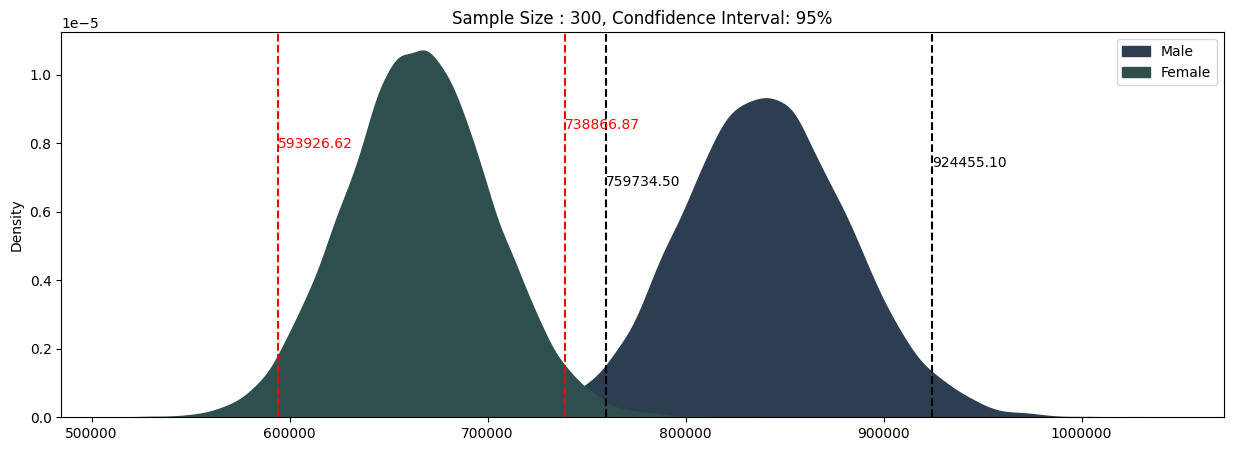

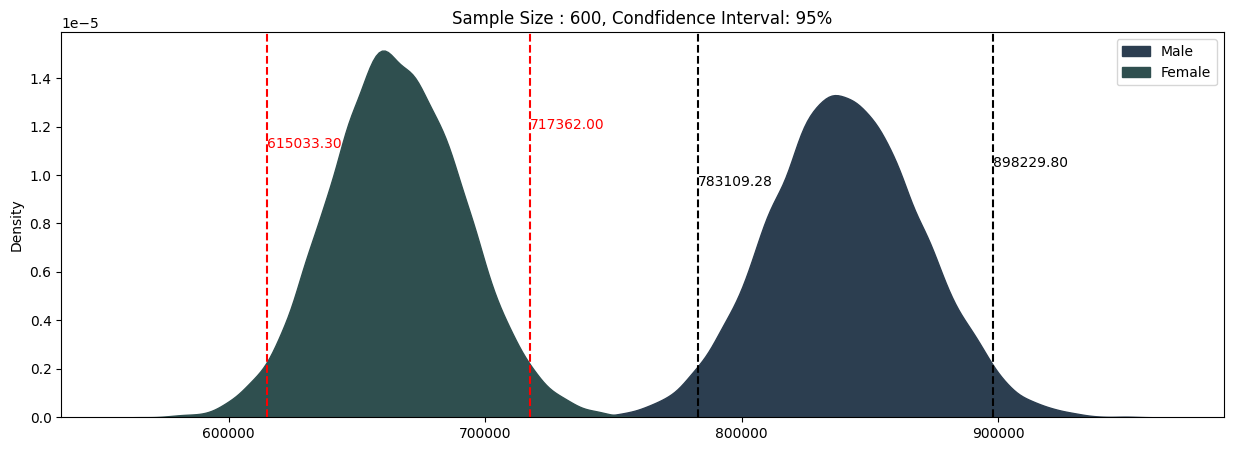

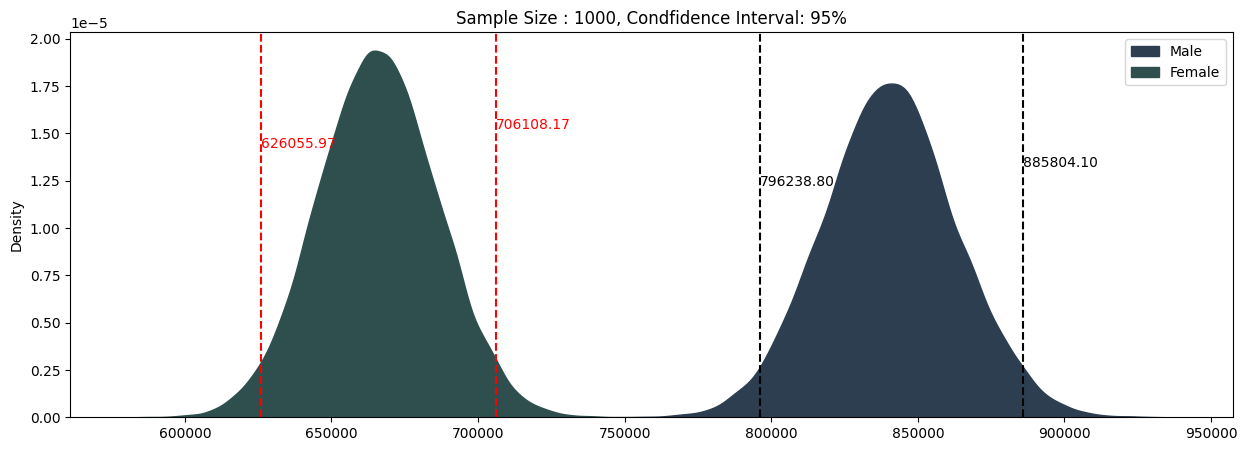

In [ ]:
male_purchase = grouped_df[grouped_df['Gender'] == 'M']['Purchase']
female_purchase = grouped_df[grouped_df['Gender'] == 'F']['Purchase']
def ci_visualization(data1,data2,colors,labels,sample_size,lp,hp,ci,sl):
  for sample in sample_size:
    #Taking samples Appliyng bootstrapping
    np.random.seed(42)
    means1 = [int(data1.sample(sample,replace = True).mean()) for i in range(20000)]
    means2 = [int(data2.sample(sample,replace = True).mean()) for i in range(20000)]

    #95% confidence interval
    low_limit1 = np.percentile(means1,lp)
    high_limit1 = np.percentile(means1,hp)
    low_limit2 = np.percentile(means2,lp)
    high_limit2 = np.percentile(means2,hp)

    interval = [low_limit1,high_limit1,low_limit2,high_limit2]
    height= iter([.6,.65,.7,.75])
    clr = iter(['black','black','red','red'])
    clr2 = iter(['black','black','red','red'])


    plt.figure(figsize=(15,5))
    sns.kdeplot(means1,fill = True,color = colors[0],label = labels[0],alpha = 1)
    sns.kdeplot(means2,fill = True,color = colors[1],label = labels[1],alpha = 1)

    for _ in interval:
      plt.axvline(_,color = next(clr),linestyle = '--')
      plt.text(_,plt.ylim()[1]*next(height),f'{_:.2f}', color = next(clr2))
    plt.legend()
    plt.ticklabel_format(style = 'plain', axis ='x')
    plt.title(f'Sample Size : {sample}, Condfidence Interval: {ci}%')
    plt.show()


sample_size = [300,600,1000]
l = ['Male','Female']
ci_visualization(male_purchase,female_purchase,color,l,sample_size,2.5,97.5,95,.05)

* Confidence interval is not overlapping even with a small sample size.

* Based on largest sample size(1000) we are 95% sure that female and  
male average spending per transaction are in the range of 626055-706109  
 and 796238-885805 respectively.

* Male mean distribution is little bit wider,indicates high variance.


In [ ]:
# Comparing bootstrapping Confidence Interval with clt Confidence interval.
from scipy.stats import norm
def ci_clt(sample_size, CI):
  for i in sample_size:
    np.random.seed(8)
    male_sample= male_purchase.sample(i, replace = True)
    female_sample= female_purchase.sample(i, replace = True)

    male_mean = male_sample.mean()
    female_mean = female_sample.mean()
    male_std_err = male_sample.std()/np.sqrt(i)
    female_std_err = female_sample.std()/np.sqrt(i)

    Female_interval = norm.interval(CI,loc = female_mean,scale = female_std_err)
    Male_interval = norm.interval(CI,loc = male_mean,scale = male_std_err)

    print(f'''Sample Size: {i}
Female {CI}% Confidence Interval: Lower Limit = {Female_interval[0]:.2f}, Upper Limit = {Female_interval[1]:.2f}
Male {CI}% Confidence Interval: Lower Limit = {Male_interval[0]:.2f}, Upper Limit = {Male_interval[1]:.2f}
------------------------------------------------------------------------------------------------------------------
                                                               ''' )

ci_clt(sample_size,.95)

Sample Size: 300
Female 0.95% Confidence Interval: Lower Limit = 565796.19, Upper Limit = 704430.16
Male 0.95% Confidence Interval: Lower Limit = 831183.40, Upper Limit = 1006448.74
------------------------------------------------------------------------------------------------------------------
                                                               
Sample Size: 600
Female 0.95% Confidence Interval: Lower Limit = 611376.54, Upper Limit = 716535.78
Male 0.95% Confidence Interval: Lower Limit = 785154.71, Upper Limit = 902397.25
------------------------------------------------------------------------------------------------------------------
                                                               
Sample Size: 1000
Female 0.95% Confidence Interval: Lower Limit = 622872.76, Upper Limit = 702017.12
Male 0.95% Confidence Interval: Lower Limit = 797104.30, Upper Limit = 888175.06
-------------------------------------------------------------------------------------------------

* Confidence Interval using Bootstraping and Central Limit Theorem are very close to each other.


**Q. What is the main reason behind revenue generation based on transaction of both genders?**

* There are 2 potential reasons:
1. Distribution of customers.
2. Average Per transaction during black friday.

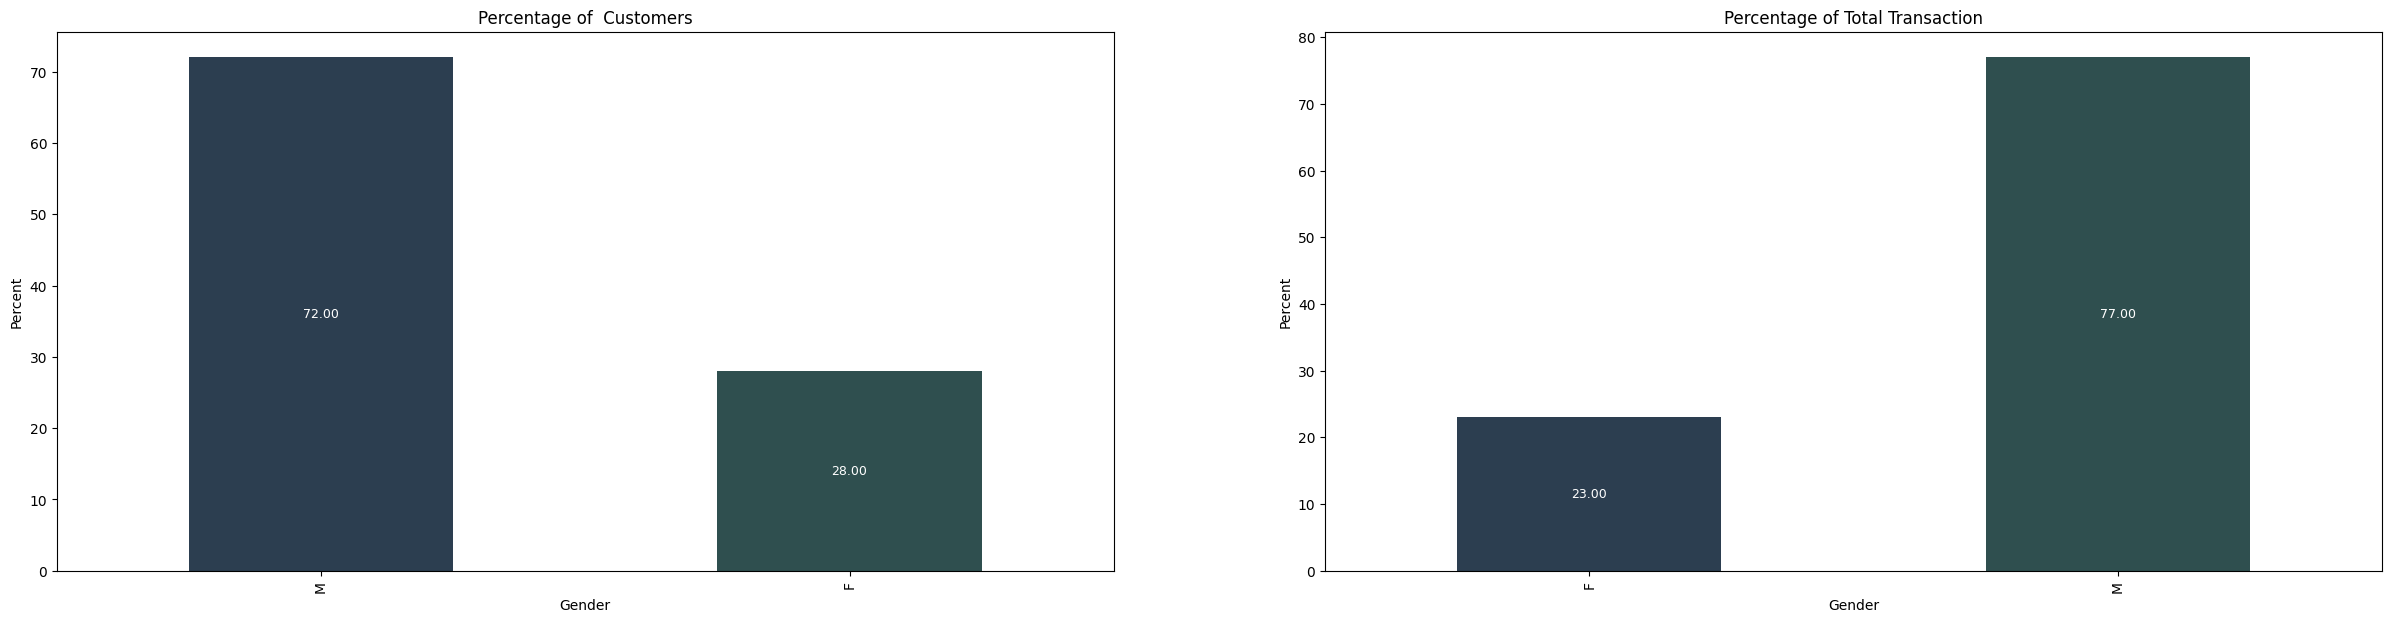

In [ ]:
fig, ax = plt.subplots(1,2,figsize =(30,7))

# percentage of total customers
gender_percent = round(customer_per_gender/sum(customer_per_gender)*100)
gender_transaction_percent = round(total_transaction_per_gender/sum(total_transaction_per_gender)*100)
gender_percent.plot(kind = 'bar', color = color, ax = ax[0])
ax[0].set_xlabel('Gender')
ax[0].set_ylabel('Percent')
ax[0].set_title('Percentage of  Customers')
for container in ax[0].containers:
  ax[0].bar_label(container, fmt='{:,.2f}',label_type='center', fontsize=9,rotation=0,color ='white')


# percentage of total transaction
gender_transaction_percent.plot(kind = 'bar',color = color,ax = ax[1])
ax[1].set_xlabel('Gender')
ax[1].set_ylabel('Percent')
ax[1].ticklabel_format(style='plain', axis='y')
ax[1].set_title('Percentage of Total Transaction')
for container in ax[1].containers:
  ax[1].bar_label(container, fmt='{:,.2f}',label_type='center', fontsize=9,rotation=0,color ='white')

plt.show()


* Percentage of female customers ar 28% and they generates 23% revenue.
* 72% male customers generate 77% revenue.

**Conclusion:**

* revenue is largely dependent on customer distribution,majority of customers   
  are male and their transaction generates large portion of revenue.


**Q. Visualse the impact of average per transaction.**

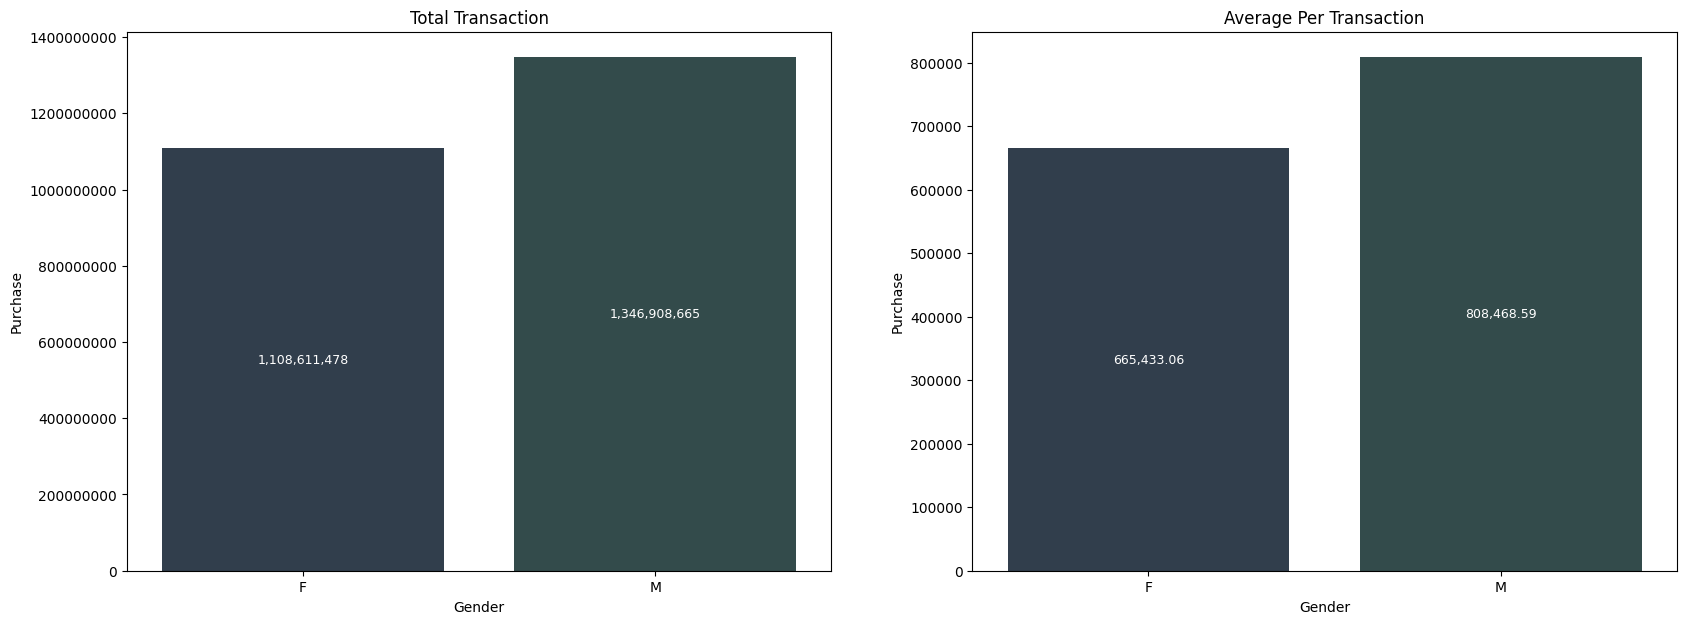

In [ ]:
# taking same number of samples from both genders to visualize the impact of average on total transaction.
samples = pd.concat((grouped_df[grouped_df['Gender'] =='F'][['Gender','Purchase']].sample(len(female_purchase),random_state=42),
                    grouped_df[grouped_df['Gender'] =='M'][['Gender','Purchase']].sample(len(female_purchase),random_state=42))).reset_index(drop = True)


fig, ax = plt.subplots(1,2,figsize =(20,7))

sns.barplot(x = 'Gender', y = 'Purchase', data = samples,estimator = 'sum', errorbar = None, palette = color, ax = ax[0])
ax[0].ticklabel_format(style='plain', axis='y')
ax[0].set_title('Total Transaction')
for container in ax[0].containers:
  ax[0].bar_label(container, fmt='{:,.0f}',label_type='center', fontsize=9,rotation=0,color ='white')


sns.barplot(x = 'Gender', y = 'Purchase', data = samples,errorbar = None, palette = color, ax = ax[1])
ax[1].set_title('Average Per Transaction')
for container in ax[1].containers:
  ax[1].bar_label(container, fmt='{:,.2f}',label_type='center', fontsize=9,rotation=0,color ='white')


plt.show()


* With equal number of customers,male average per transaction is creating   
 difference between male and female total transaction, states difference in  
  their purchasing behaviour.

**Q. What elevates Male average per transaction?**

**2 potential reasons:**

1. Males are purchasing expensive products.
2. Males are purchasing more quantity of same products compare to Females.
3. Number of unique products purchased by Males are greater than Females per Customer.

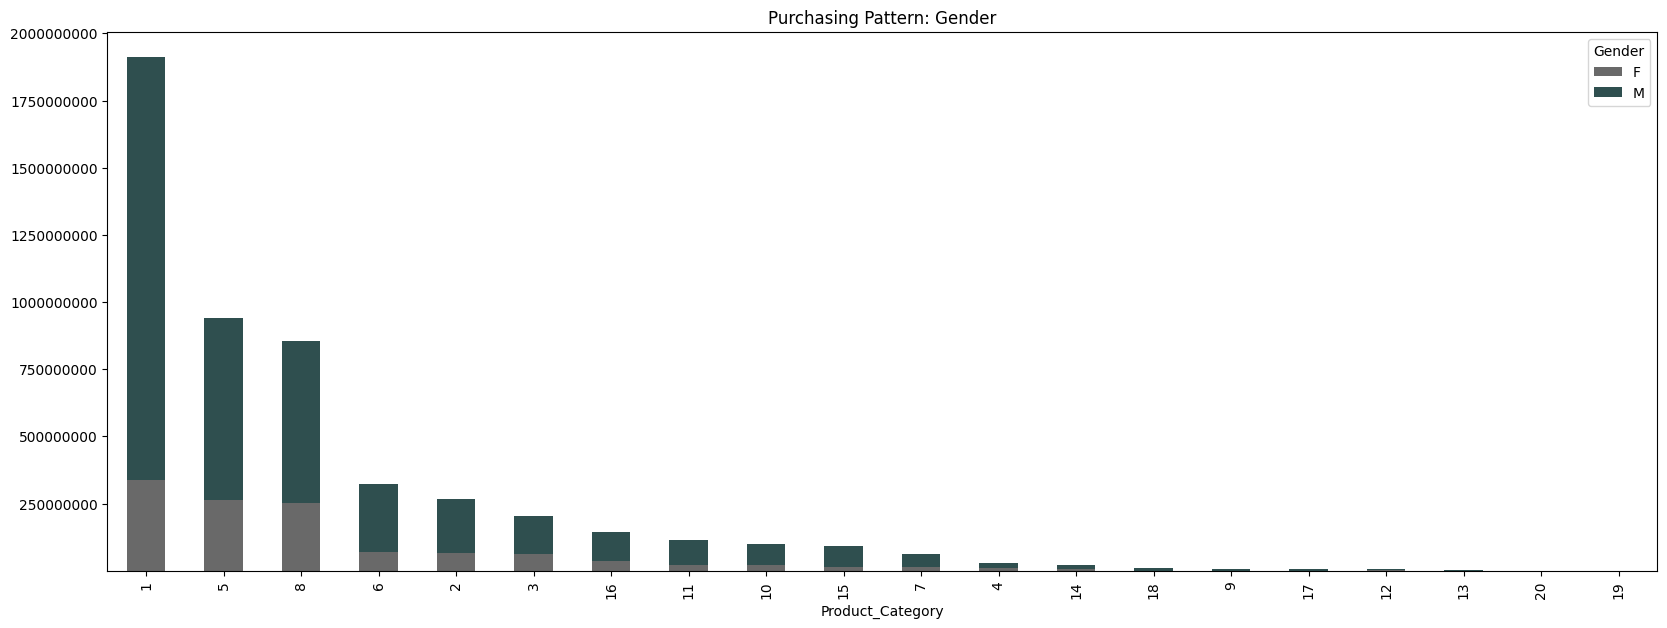

In [ ]:
# Preferred product categories by both the genders.
gender_pc_data = df.groupby(['Product_Category','Gender'])['Purchase'].sum().unstack().sort_values(by = ['M','F'],ascending = False)
fig, ax = plt.subplots(figsize =(20,7))
gender_pc_data.plot(kind = 'bar', stacked= True,color= color2, ax = ax)
ax.ticklabel_format(style='plain', axis='y')
ax.set_title('Purchasing Pattern: Gender')
plt.show()

* Purchasing pattern are similar, Male and Female prefers similar kind of products.

In [ ]:
# Creating labels fpr top 3 category and others
top_3_pc =[1,5,8]
df['PC_Label'] = df.Product_Category.map(lambda x : 'top_3' if x in top_3_pc else 'others')

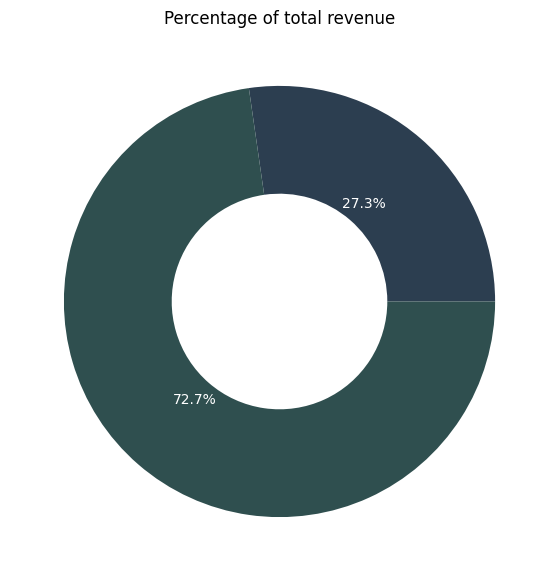

In [ ]:
# checking percentage of revenue generated by top3 products category compare to others.
plt.figure(figsize = (15,7))
plt.pie(df.groupby('PC_Label')['Purchase'].sum(),labels=df.groupby('PC_Label')['Purchase'].sum().index
        ,autopct='%1.1f%%',wedgeprops={'width': 0.5}, colors = color,textprops={'color': 'white'})
plt.title('Percentage of total revenue')
plt.show()

* Around 73% of total revenue has been generated product Category category 1,5 and 8.

* These 3 categories could be used to determine purchasing behaviour.

In [ ]:
# creating data where only top 3 product category exists.
top_3_pc =[1,5,8]
top_3_pc_df = df[df.Product_Category.isin(top_3_pc)]

* Since,  price and quantity column are not available we can't determine  
  actual price of any product, but we can still find who is purchasing   
  more quantity by comparing their total spending on each product.

In [ ]:
top_3_pc_df.Product_ID.nunique()

2507

* There are 2507 different products in top 3 product Category.
* comparing 2507 different products is very expensive, we can  
  compare top 20 products.

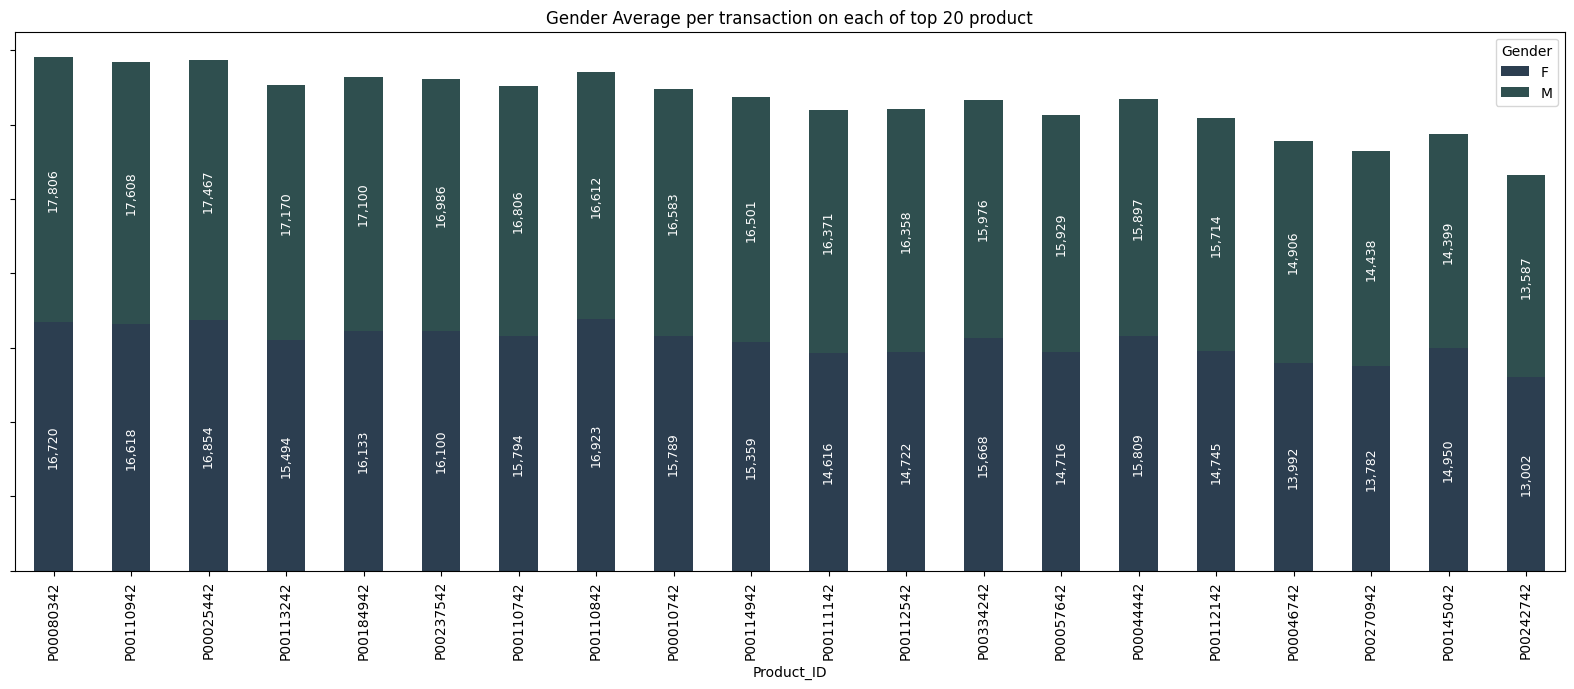

In [ ]:
# top 20 products with most revenue in top 3 product category.
top_20_products = top_3_pc_df.groupby('Product_ID')['Purchase'].sum().nlargest(20).index

# Gender's average per transaction/customer on each of top 20 products.
gender_spending = top_3_pc_df[top_3_pc_df.Product_ID.isin(top_20_products)].groupby(['Product_ID',
                  'Gender'])['Purchase'].mean().unstack().sort_values(by = ['M','F'], ascending = False)

fig, ax = plt.subplots(figsize =(20,7))
gender_spending.plot(kind = 'bar', stacked = True, color = color, ax =ax)
ax.ticklabel_format(style='plain', axis='y')
ax.set_title('Gender Average per transaction on each of top 20 product')
ax.set_yticklabels([])
for container in ax.containers:
  ax.bar_label(container, fmt='{:,.0f}',label_type='center', fontsize=9,rotation=90, color ='white')
plt.show()

* Male average per transaction on top 20 products is  greater than female, by a significant margin(there are 1 or 2 exceptions).

* Price of each product must be same for both, still male average spending on majority of products are high, clearly states that  
 male are purchasing more quantity of same product compare to female which elevates their average per transaction.




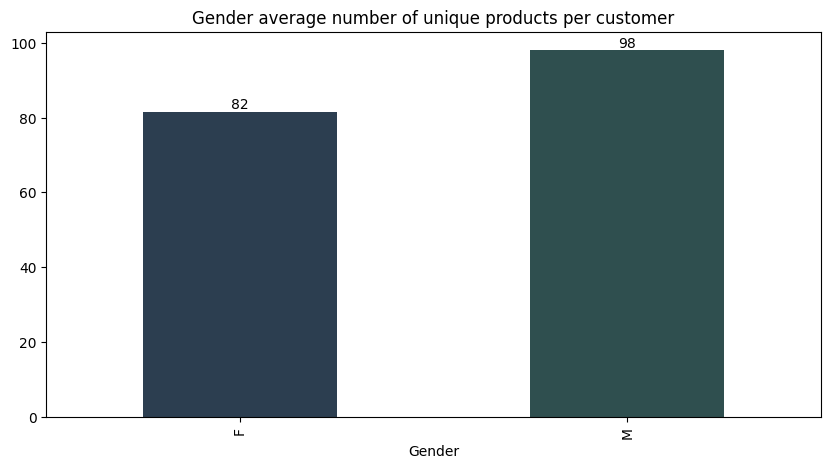

In [ ]:
# Average Number of different products purchased by male and female per customer.
gender_num_products = df.groupby(['Gender','User_ID'])['Product_ID'].nunique().reset_index().groupby('Gender')['Product_ID'].mean()
fig, ax = plt.subplots(figsize =(10,5))
gender_num_products.plot(kind = 'bar', color = color, ax =ax)
ax.ticklabel_format(style='plain', axis='y')
ax.set_title('Gender average number of unique products per customer')
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.show()

* Number of different products on an average per customer is also greater for Male.

**Conclusion:**


* Combining both the factors (quantity purchased per product and number of  
  different products per customer is greater for male),we can conclude that both   
  the factors are contributing to high average per transaction of male.



* purchasing behaviour of male and female differs in terms of quantity of products  
 they purchase while it is similar in terms of their purchasing pattern(types of product  
  they prefer).

* Spending habit of Male and Female are different as males are spending  
 significantly greater than females, per customer.

# Martial Status Column Analysis



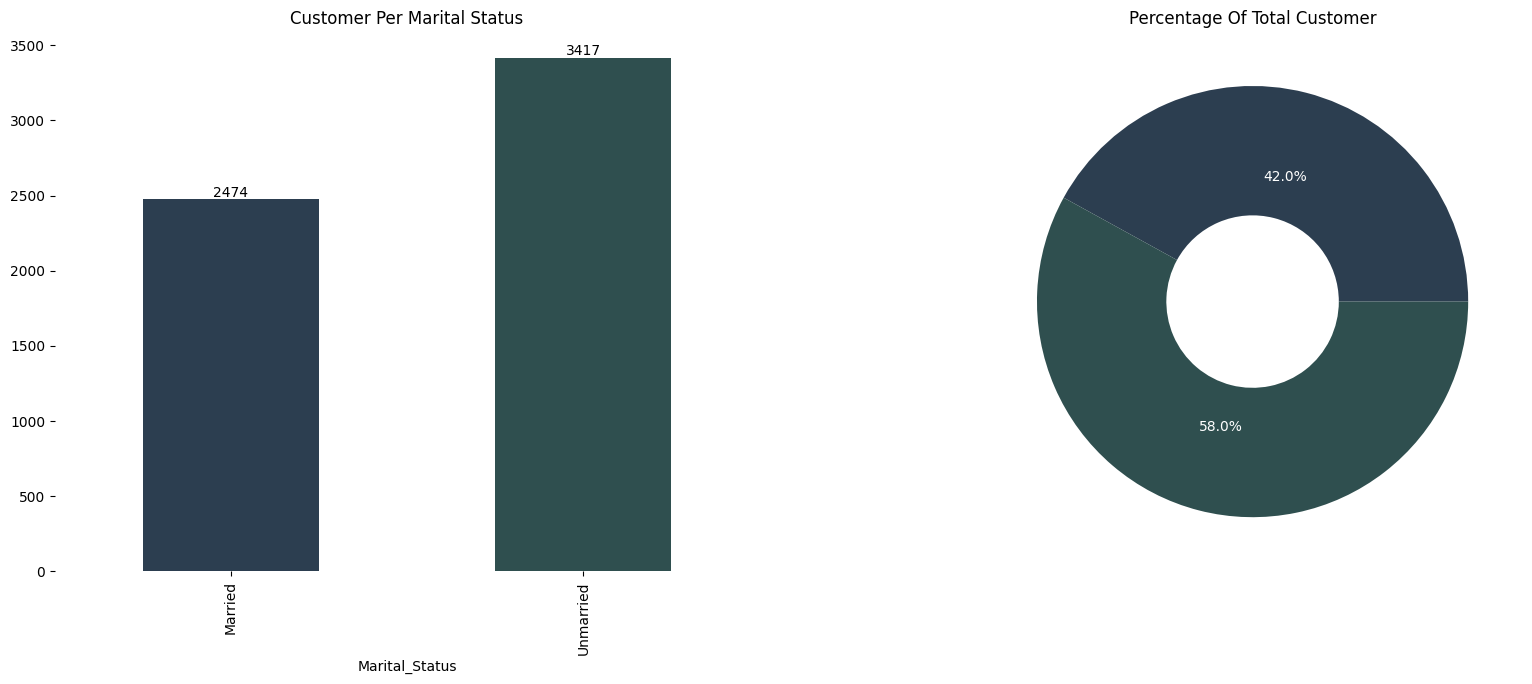

In [ ]:
customer_per_MS =df.groupby('Marital_Status')['User_ID'].nunique()
fig,ax =plt.subplots(1,2,figsize = (20,7))
customer_per_MS.plot(kind = 'bar', color = color, ax =ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].set_title('Customer Per Marital Status')
for spine in ax[0].spines.values():
    spine.set_visible(False)

customer_per_MS.plot(kind = 'pie',wedgeprops={'width':0.6}, autopct ='%1.1f%%', colors = color,ax =ax[1],textprops={'color': 'white'})
ax[1].set_title('Percentage Of Total Customer')
ax[1].set_ylabel('')
plt.show()
plt.show()


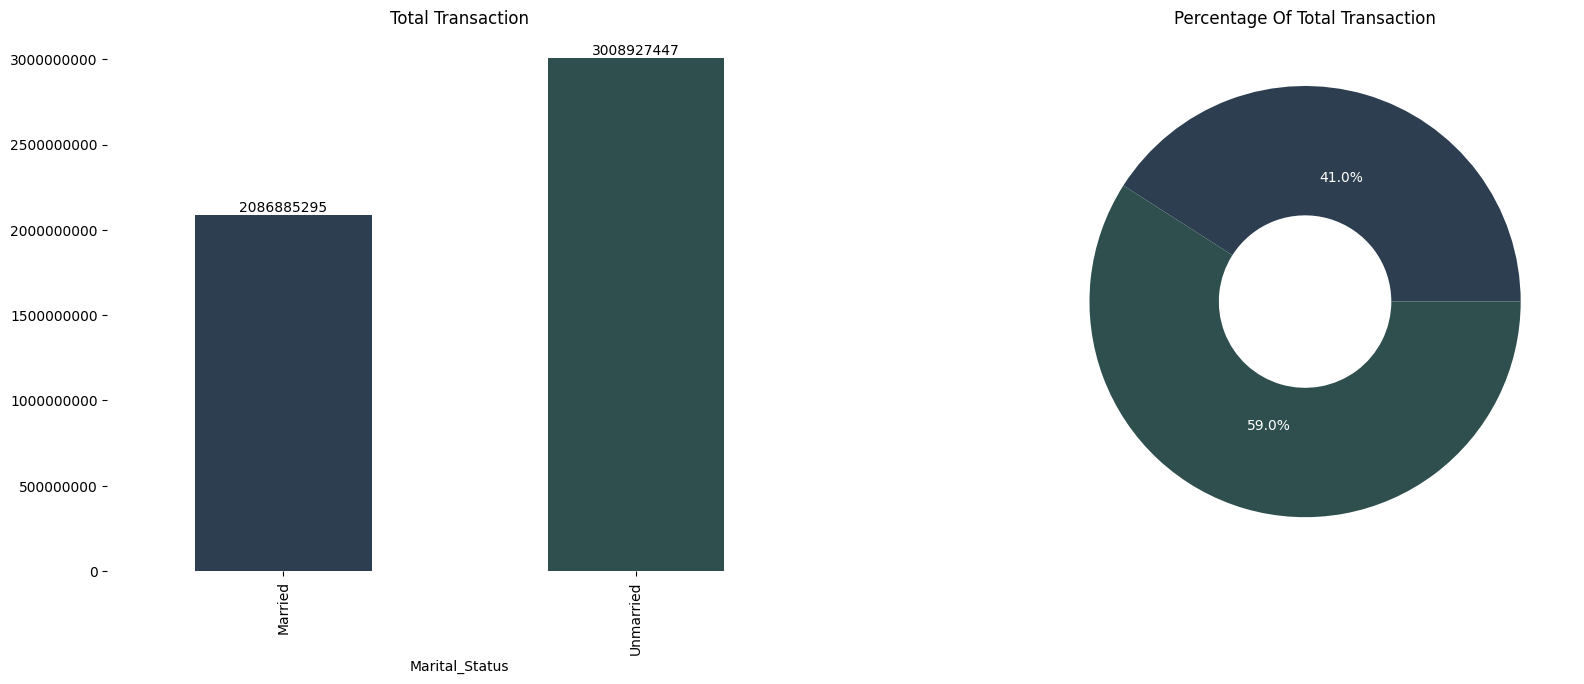

In [ ]:
total_transaction_per_MS= df.groupby('Marital_Status')['Purchase'].sum()
fig,ax =plt.subplots(1,2,figsize = (20,7))
total_transaction_per_MS.plot(kind = 'bar', color = color, ax =ax[0])
ax[0].ticklabel_format(style = 'plain', axis = 'y')
ax[0].bar_label(ax[0].containers[0],fmt='%.0f')
ax[0].set_title('Total Transaction')
for spine in ax[0].spines.values():
    spine.set_visible(False)

total_transaction_per_MS.plot(kind = 'pie',wedgeprops={'width':0.6}, autopct ='%1.1f%%', colors = color,ax =ax[1],textprops={'color': 'white'})
ax[1].set_title('Percentage Of Total Transaction')
ax[1].set_ylabel('')
plt.show()


* 59% of total transaction done by 58% Unmarried customers while   
  41% of total transaction is done by 42% of Married customers.



# confidence interval 2

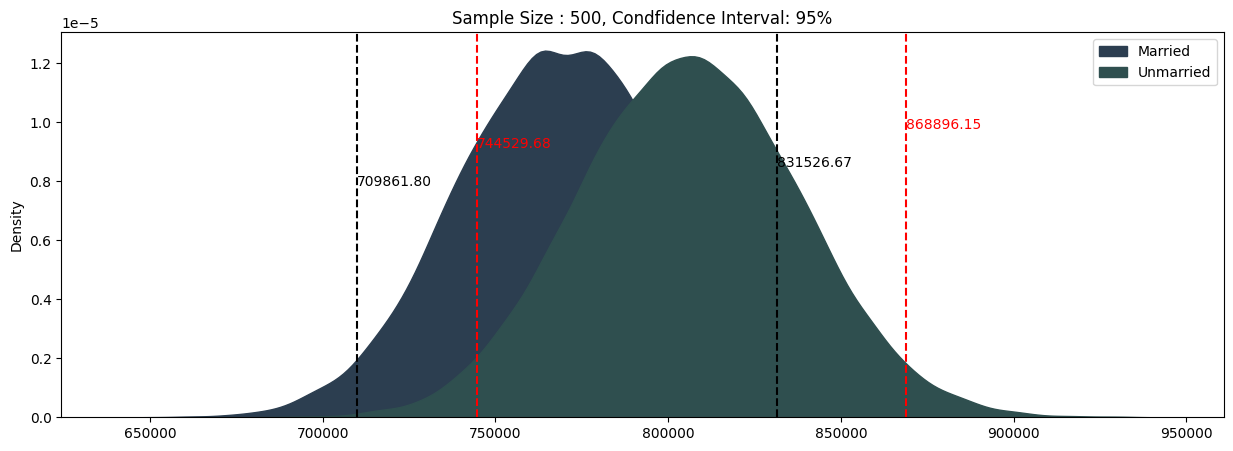

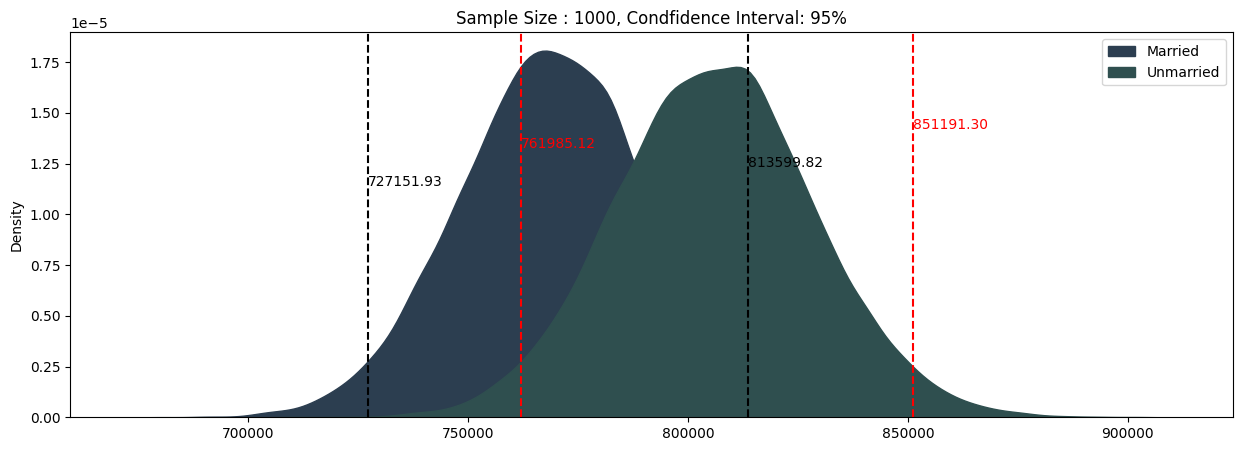

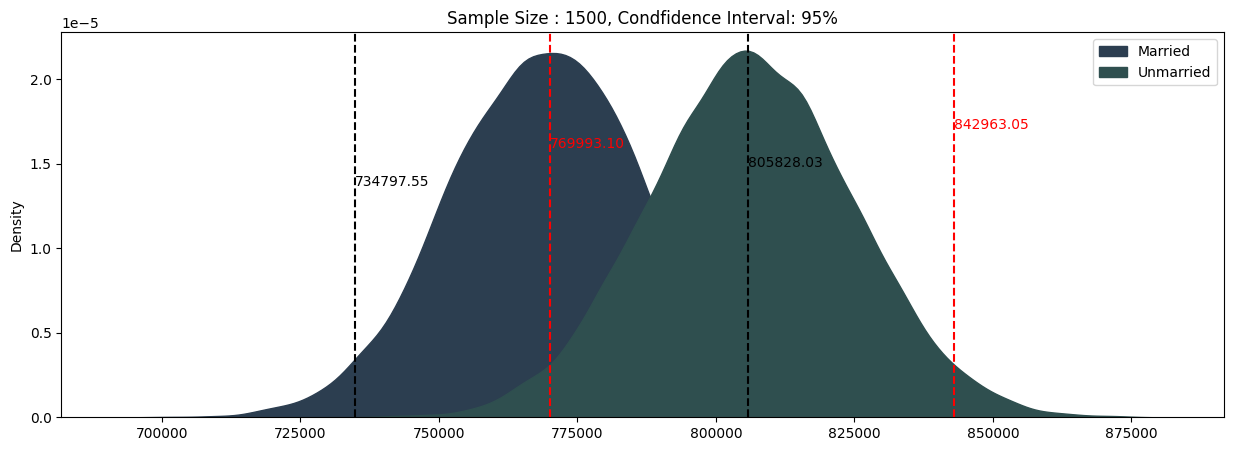

In [ ]:
married_purchase = grouped_df[grouped_df['Marital_Status'] == 'Married']['Purchase']
unmarried_purchase = grouped_df[grouped_df['Marital_Status'] == 'Unmarried']['Purchase']
sample_size = [500,1000,1500]
c = ['olive','teal']
l2 = ['Married','Unmarried']
ci_visualization(married_purchase,unmarried_purchase,color,l2,sample_size,2.5,97.5,95,.05)


* Confidence interval is overlapping for married and unmarried Customers.  
  however, overlapping gradually decreases with increase in sample size.

# Hypothesis testing 1


In [ ]:
# Function to test mean of a category is different from other or not.
def hypothesis_testing(d1,d2,sample_size,ci,si,label):

    # setting sample size = total length of category with less customer
    sample1 = d1.sample(len(d2))
    sample2 = d2

    test_stat,pvalue = ttest_ind(sample1,sample2)
    if pvalue < si:
      print(f'sample Size: {sample_size}, Confidence level: {ci}%')
      print(f'''P-value{pvalue} < {si} thus, we reject the null hypothesis.
Average per Transaction amount of {label[0]} is different from {label[1]}.

''')
    else:
      print(f'sample Size: {sample_size}, Confidence level: {ci}%')
      print(f'''P-value{pvalue} > {si} thus, we failed to reject the null hypothesis.
Average per Transaction of {label[0]} is not different from {label[1]}.

''')

hypothesis_testing(unmarried_purchase,married_purchase,len(married_purchase),95,.05,['unmarried','married'])

sample Size: 2474, Confidence level: 95%
P-value0.20096197861367218 > 0.05 thus, we failed to reject the null hypothesis.
Average per Transaction of unmarried is not different from married.




* since, P-value > .05 it must be greater than 0, Therefore we are 100% sure  
that there is no clear difference between average per transaction of married  
 and unmarried customer based on black friday data.

**Conclusion:**
> Total transaction by unmarried customers is greater than Married because  
majority of customers are unmarried. but they have similar purchasing behaviour.

# Age based analysis


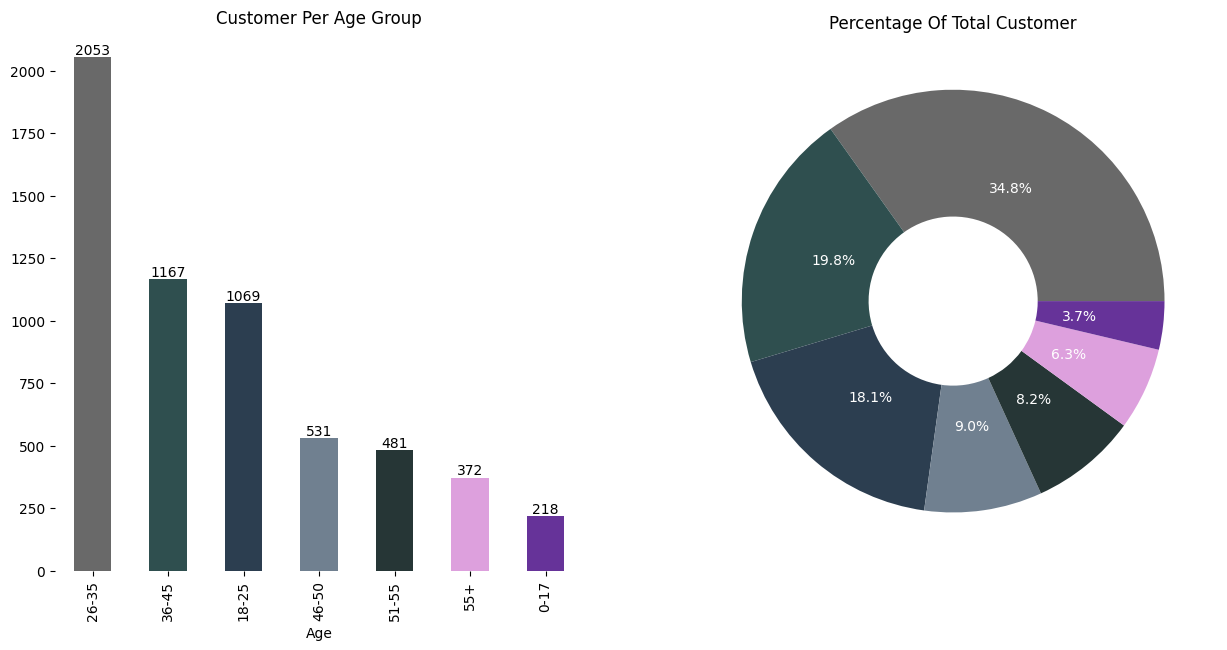

In [ ]:
c = ['dimgray','darkslategray','#2c3e50','slategray','#263636','plum','rebeccapurple','teal']
customer_per_age_group = grouped_df['Age'].value_counts()


fig,ax  = plt.subplots(1,2,figsize=(15,7))
customer_per_age_group.plot(kind = 'bar', color = c, ax =ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].set_title('Customer Per Age Group')
for spine in ax[0].spines.values():
    spine.set_visible(False)

customer_per_age_group.plot(kind = 'pie',wedgeprops={'width':0.6}, autopct ='%1.1f%%', colors = c,ax =ax[1],textprops={'color': 'white'})
ax[1].set_title('Percentage Of Total Customer')
ax[1].set_ylabel('')
plt.show()


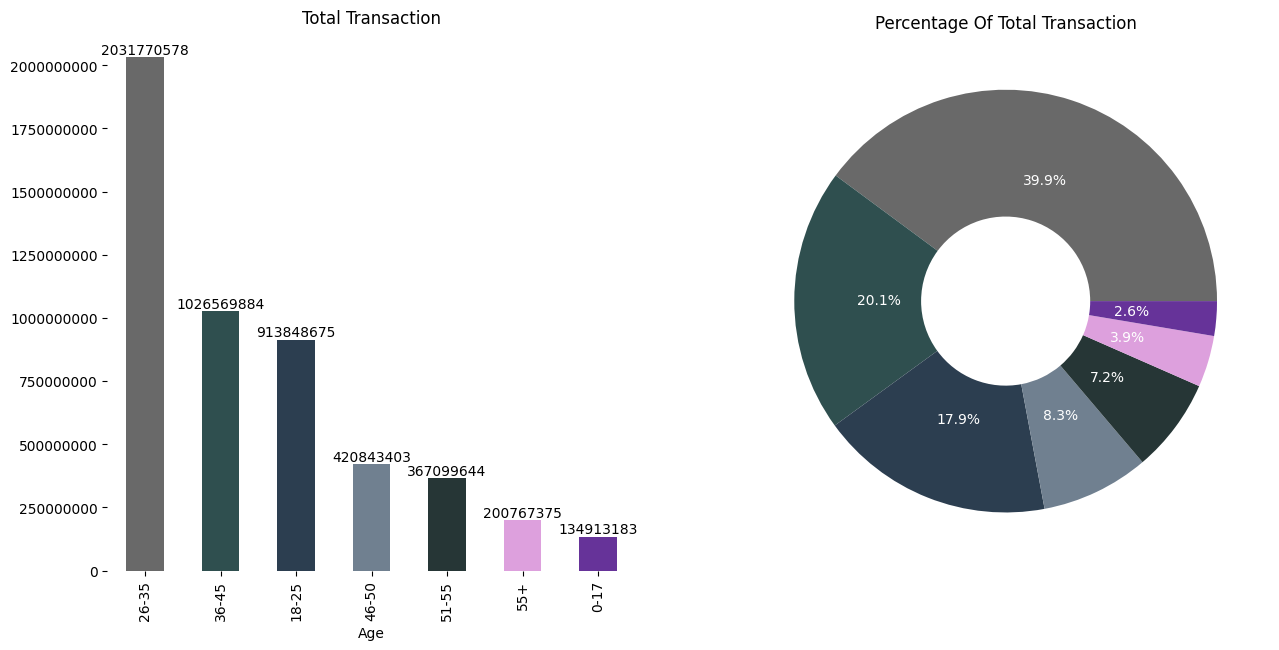

In [ ]:
total_transaction_per_age_group = df.groupby('Age')['Purchase'].sum().sort_values(ascending = False)

fig,ax  = plt.subplots(1,2,figsize=(15,7))
total_transaction_per_age_group.plot(kind = 'bar', color = c, ax =ax[0])
ax[0].ticklabel_format(style = 'plain', axis = 'y')
ax[0].bar_label(ax[0].containers[0],fmt='%.0f')
ax[0].set_title('Total Transaction')
for spine in ax[0].spines.values():
    spine.set_visible(False)

total_transaction_per_age_group.plot(kind = 'pie',wedgeprops={'width':0.6}, autopct ='%1.1f%%', colors = c,ax =ax[1],textprops={'color': 'white'})
ax[1].set_title('Percentage Of Total Transaction')
ax[1].set_ylabel('')


plt.show()


* Majority of customers belongs to 18-45 age , with a highest contribution  
 in revenue generation.
* Revenue generation is dependent of customers distribution, as groups with  
 high density of customers are generating greater revenue.

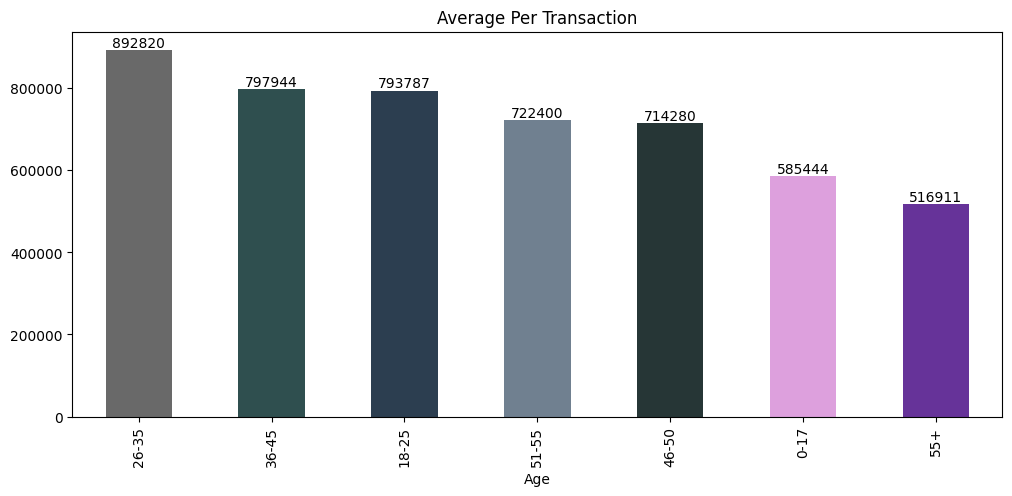

Age
26-35    892819.790550
36-45    797944.121680
18-25    793786.530402
51-55    722399.528067
46-50    714279.790960
0-17     585443.857798
55+      516910.766129
Name: Purchase, dtype: float64


In [ ]:
avg_per_transaction_age_group = grouped_df.groupby('Age')['Purchase'].mean().sort_values(ascending = False)
fig,ax =plt.subplots(figsize = (12,5))
avg_per_transaction_age_group.plot(kind = 'bar', color = c, ax =ax)
ax.ticklabel_format(style = 'plain', axis = 'y')
ax.bar_label(ax.containers[0],fmt='%.0f')
ax.set_title('Average Per Transaction')
plt.show()
print(avg_per_transaction_age_group)

* Average per transaction of 26-35 are clearly way ahead of others.

* Average per transactions of 18-25 and 36-45 are very close to each  
 other but they are  clearly less than 26-35 and clearly greater than others.

* Average per transactions of 46-50 and 51-55 are very close to each other   
  but they clearly greater than 0-17 and 55+ and lesser than others.

* Average per transaction 55+ is lesser then all the age groups.

# Confidence interval 3

In [ ]:
age_0_17 = grouped_df[grouped_df['Age'] == '0-17']['Purchase']
age_18_25 = grouped_df[grouped_df['Age'] == '18-25']['Purchase']
age_26_35 = grouped_df[grouped_df['Age'] == '26-35']['Purchase']
age_36_45 = grouped_df[grouped_df['Age'] == '36-45']['Purchase']
age_46_50 = grouped_df[grouped_df['Age'] == '46-50']['Purchase']
age_51_55 = grouped_df[grouped_df['Age'] == '51-55']['Purchase']
age_55_plus = grouped_df[grouped_df['Age'] == '55+']['Purchase']

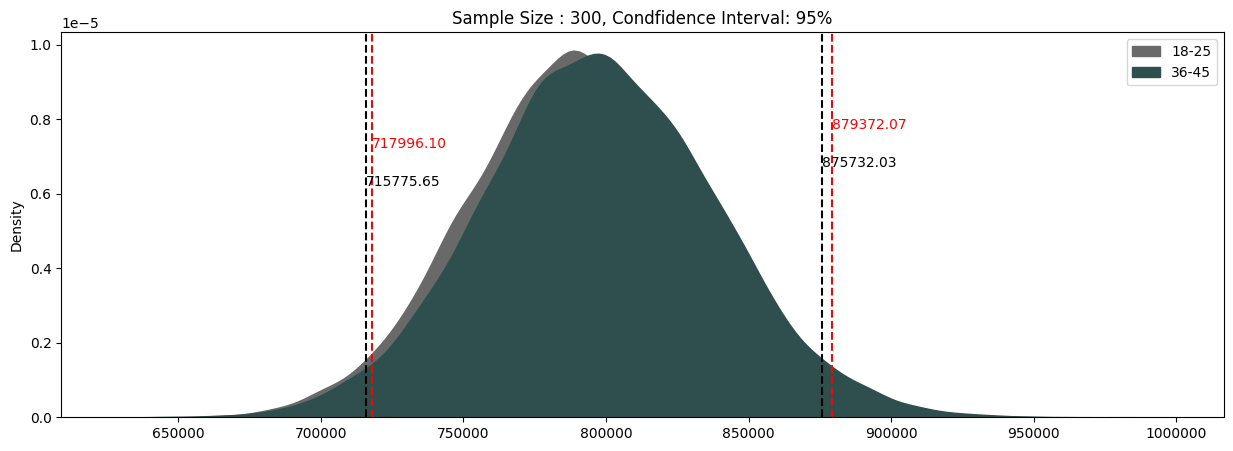

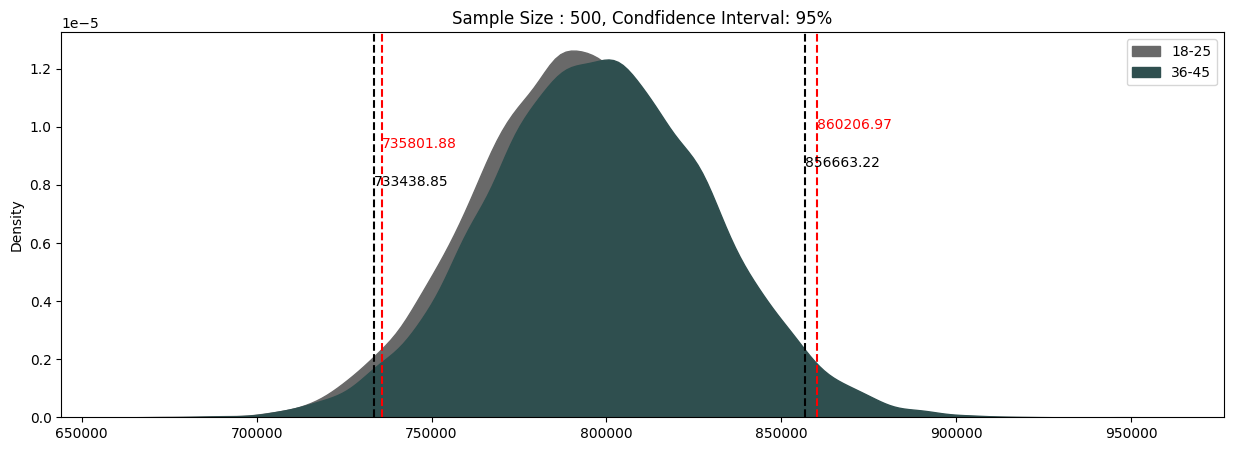

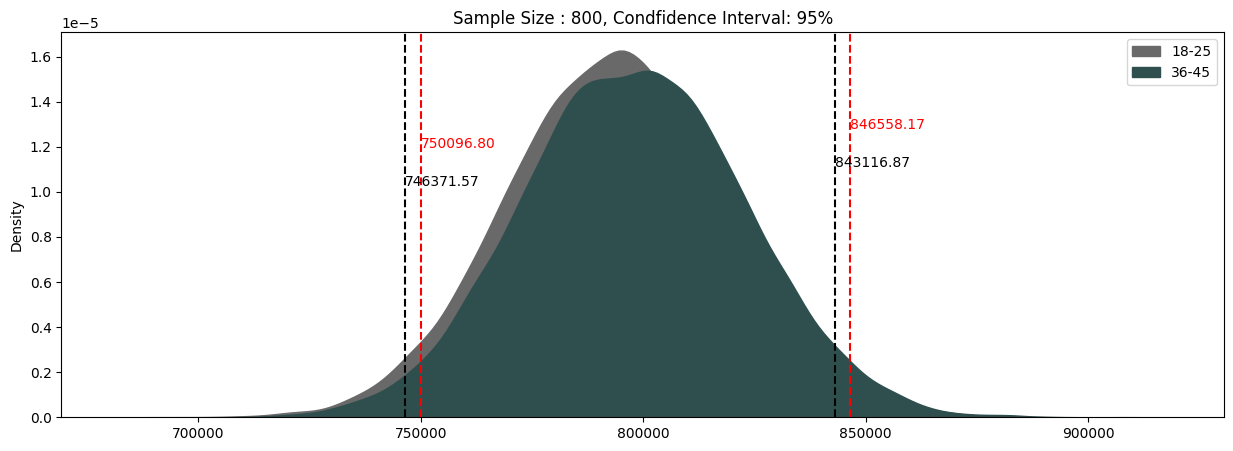

In [ ]:
# checking confidence interval of closest average
ci_visualization(age_18_25,age_36_45,color2,['18-25','36-45'],[300,500,800],2.5,97.5,95,.05)

* Highly overlapping confidence interval indicates, 18-25 and 36-45 are  
 belonging to the same mean distribution, there range of average per   
 transaction is 746371-843117 and 750096-866559 respectively.

In [ ]:
# Testing average per transaction of age 18-25 and 36-45 are different or not.
hypothesis_testing(age_36_45,age_18_25,len(age_18_25),95,.05,['36-45','18-25'])

sample Size: 1069, Confidence level: 95%
P-value0.9557389769816536 > 0.05 thus, we failed to reject the null hypothesis.
Average per Transaction of 36-45 is not different from 18-25.




* Age group 18-25 and 36-45 have same purchasing behaviour.

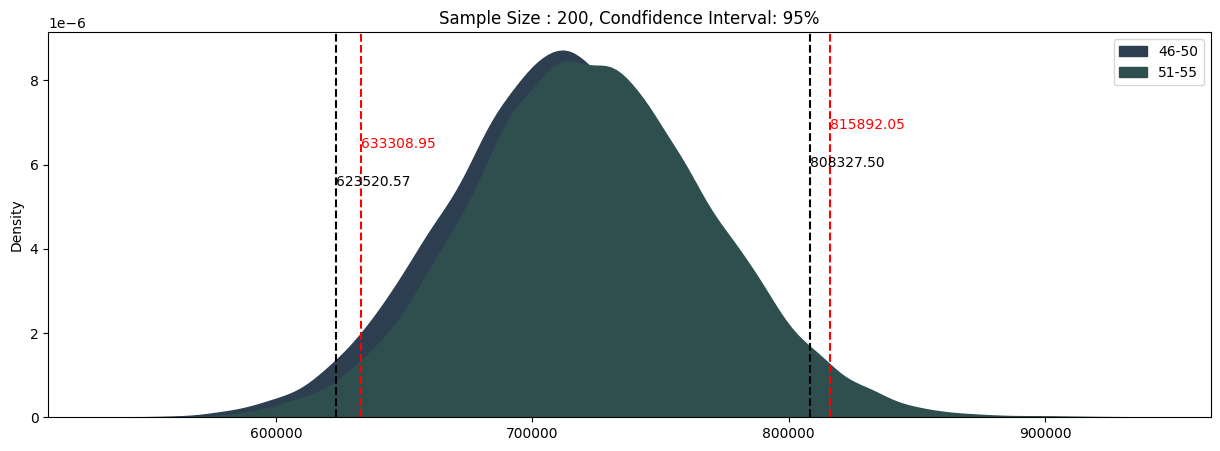

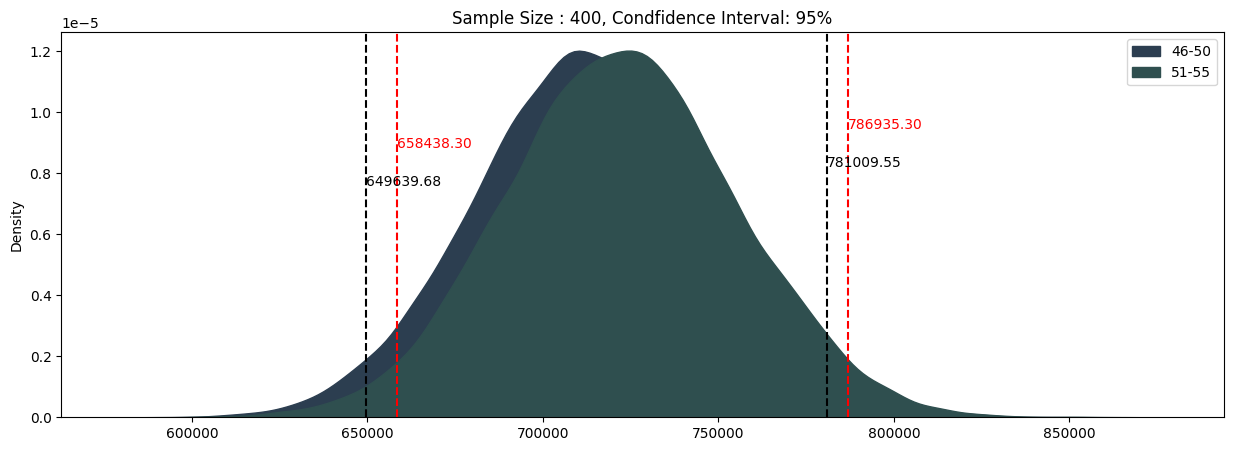

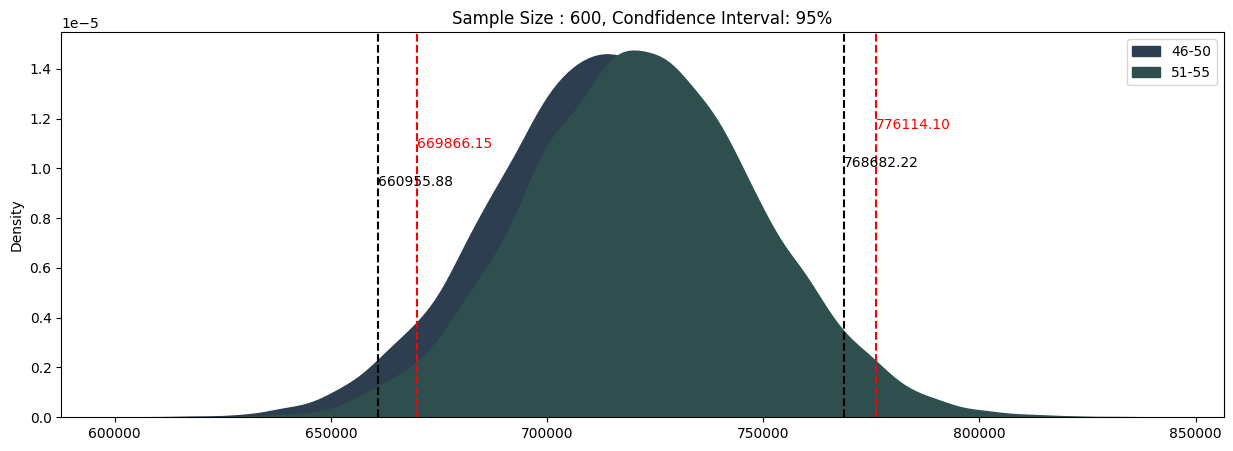

In [ ]:
# checking confidence interval of closest average
ci_visualization(age_46_50,age_51_55,color,['46-50','51-55'],[200,400,600],2.5,97.5,95,.05)

* Confidence interval of 46-50 and 51-55 is highly overlapping, their range  
  of of average per transaction is 66955-768683 and 669866-776115.

In [ ]:
# Testing average per transaction of age 18-25 and 36-45 are different or not.
hypothesis_testing(age_46_50,age_51_55,len(age_51_55),95,.05,['46-50','51-55'])

sample Size: 481, Confidence level: 95%
P-value0.8578705899490578 > 0.05 thus, we failed to reject the null hypothesis.
Average per Transaction of 46-50 is not different from 51-55.




* Age group 46-50 and 51-55 has similar purchasing behaviour.

* 26-35 are high spending age group, 18-25 and 36-45 are high-mid spending   
  group, 46-50 and 51-55 are low mid spending group and below 17 and above  
   55 are low spending age group.

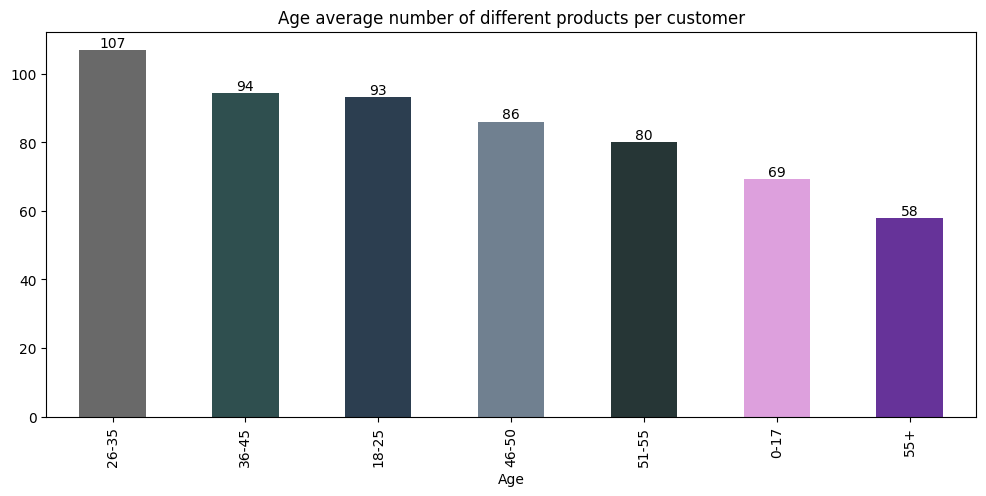

In [ ]:
num_diif_product_per_age =  df.groupby(['Age','User_ID'])['Product_ID'].nunique().reset_index(
                            ).groupby('Age')['Product_ID'].mean().sort_values(ascending = False)


fig,ax =plt.subplots(figsize = (12,5))
num_diif_product_per_age.plot(kind = 'bar', color = c, ax =ax)
ax.bar_label(ax.containers[0],fmt='%.0f')
ax.set_title('Age average number of different products per customer')
plt.show()


* Age groups with high average per transaction has purchased more products  
 compare to others.
* Similar to gender, frequency of products contributes to average per transaction.

# City category column Analysis.

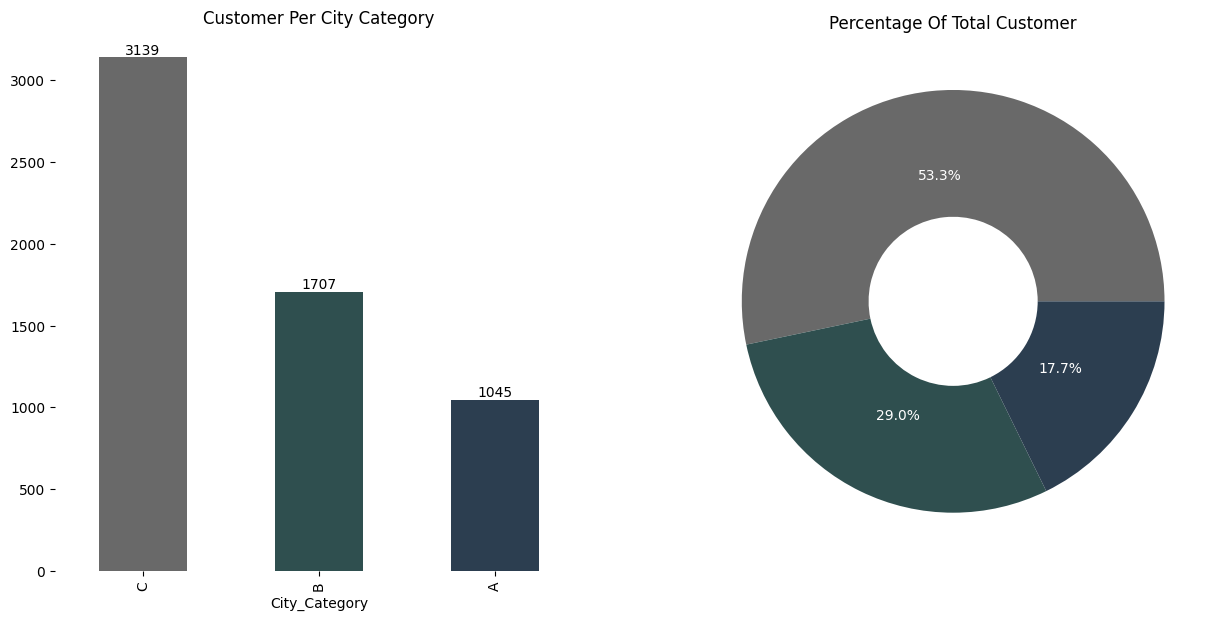

In [ ]:
customer_per_city_cat = grouped_df.City_Category.value_counts()

fig,ax  = plt.subplots(1,2,figsize=(15,7))
customer_per_city_cat.plot(kind = 'bar', color = c, ax =ax[0])
ax[0].bar_label(ax[0].containers[0])
ax[0].set_title('Customer Per City Category')
for spine in ax[0].spines.values():
    spine.set_visible(False)

customer_per_city_cat.plot(kind = 'pie',wedgeprops={'width':0.6}, autopct ='%1.1f%%', colors = c,ax =ax[1],textprops={'color': 'white'})
ax[1].set_title('Percentage Of Total Customer')
ax[1].set_ylabel('')
plt.show()

plt.show()

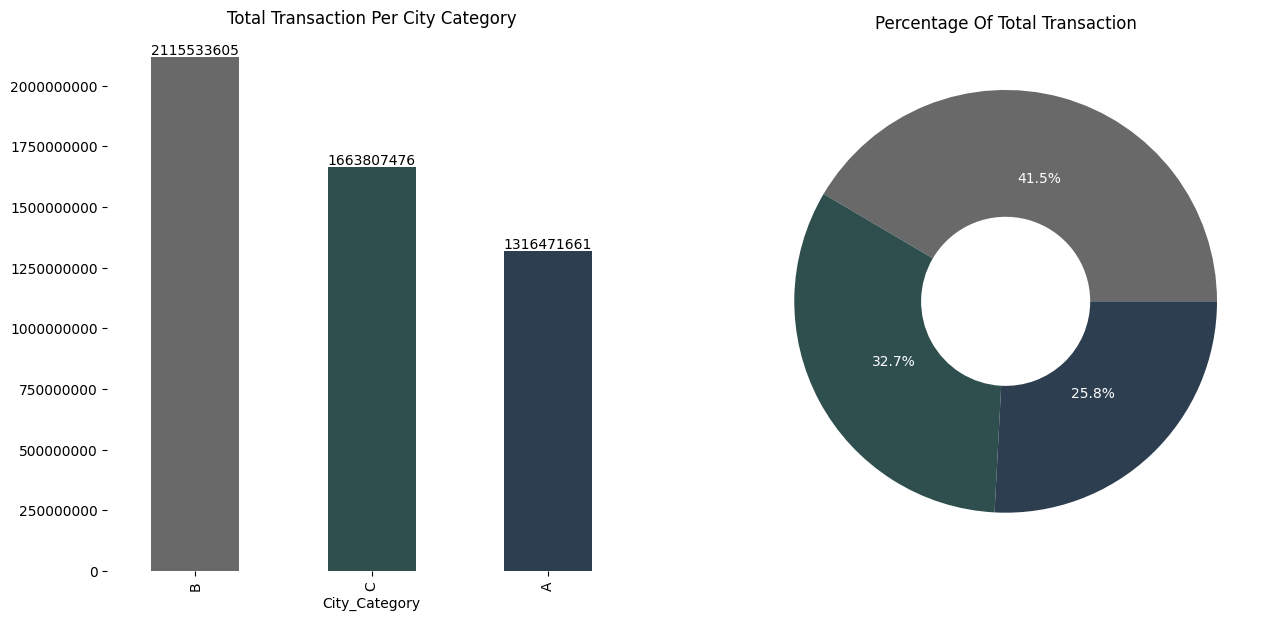

In [ ]:
total_transaction_per_city_cat = df.groupby('City_Category')['Purchase'].sum().sort_values(ascending = False)

fig,ax  = plt.subplots(1,2,figsize=(15,7))
total_transaction_per_city_cat.plot(kind = 'bar', color = c, ax =ax[0])
ax[0].bar_label(ax[0].containers[0], fmt = '%.0f')
ax[0].ticklabel_format(style = 'plain', axis = 'y')
ax[0].set_title('Total Transaction Per City Category')
for spine in ax[0].spines.values():
    spine.set_visible(False)

total_transaction_per_city_cat.plot(kind = 'pie',wedgeprops={'width':0.6}, autopct ='%1.1f%%', colors = c,ax =ax[1],textprops={'color': 'white'})
ax[1].set_title('Percentage Of Total Transaction')
ax[1].set_ylabel('')
plt.show()

plt.show()

* Revenue generation in city category is not dependent on customer   
concentration, City Category B with just 29% total customers are   
generatiog 41.5% of total revenue and City Category C with 53.3%   
of total customers are generating just 32.7% of total revenue.

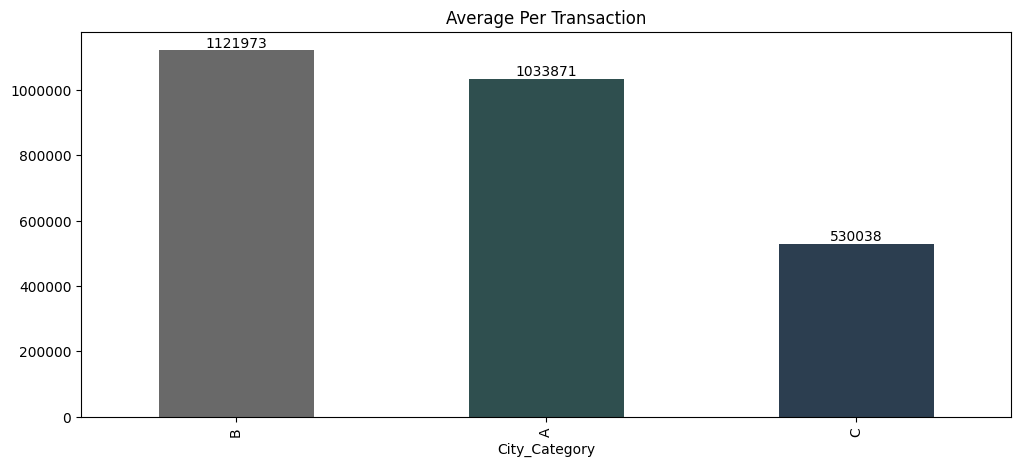

In [ ]:
# Average per transaction
avg_transaction_per_city_cat = grouped_df.groupby('City_Category')['Purchase'].mean().sort_values(ascending = False)
fig,ax =plt.subplots(figsize = (12,5))
avg_transaction_per_city_cat.plot(kind = 'bar', color = c, ax =ax)
ax.ticklabel_format(style = 'plain', axis = 'y')
ax.bar_label(ax.containers[0],fmt='%.0f')
ax.set_title('Average Per Transaction')
plt.show()

* In case of city category Average per transaction is the main reason behind  
 revenue generation.
* Aveage per transaction of City Category B > A > C, by a significant margin.

Q. Why Average Per transaction of City Category C is very less?

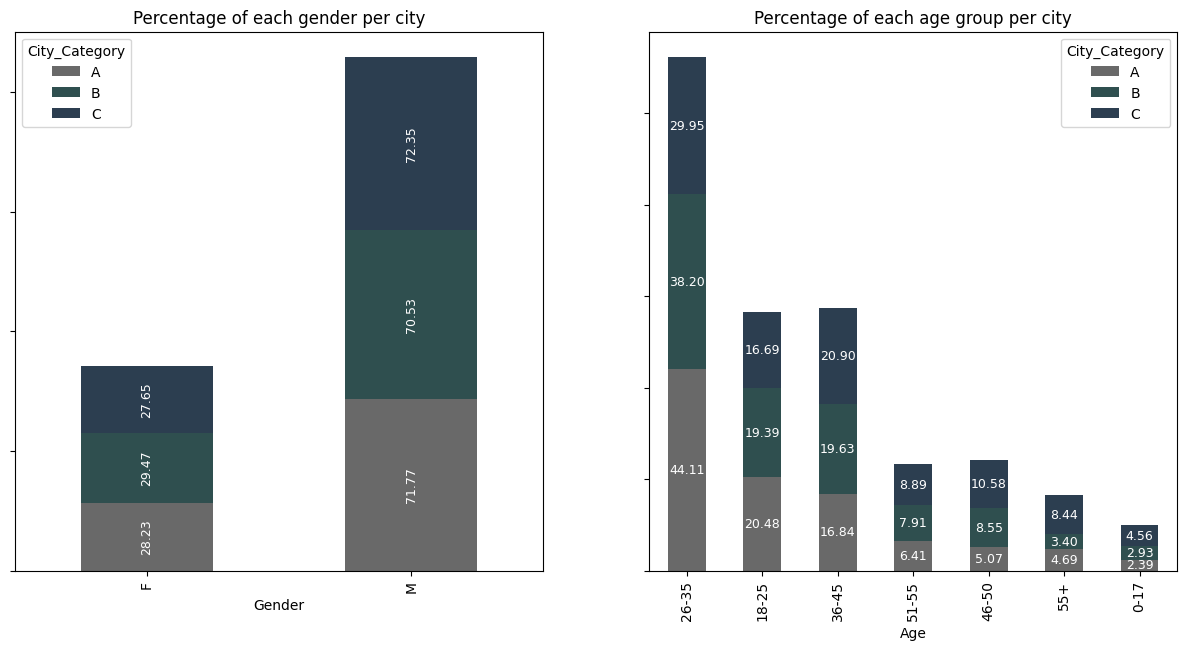

In [ ]:
# percentage of male and female customers.
gender_percentage = pd.crosstab(index = grouped_df['Gender'], columns= grouped_df['City_Category'], normalize = 'columns')*100
age_percentage = pd.crosstab(index = grouped_df['Age'], columns= grouped_df['City_Category'], normalize = 'columns'
                 ).sort_values(by = ['A','B','C'], ascending = False)*100

fig,ax = plt.subplots(1,2, figsize = (15,7))
gender_percentage.plot(kind = 'bar',stacked = True, color = c, ax =ax[0])
for i in ax[0].containers:
  ax[0].bar_label(i, fmt = '%.2f',label_type='center', fontsize=9,rotation=90,color ='white')
ax[0].set_title('Percentage of each gender per city')
ax[0].set_yticklabels([])



age_percentage.plot(kind = 'bar',stacked = True, color = c, ax =ax[1])
for i in ax[1].containers:
  ax[1].bar_label(i, fmt = '%.2f',label_type='center', fontsize=9,rotation=0,color ='white')
ax[1].set_title('Percentage of each age group per city')
ax[1].set_yticklabels([])
plt.show()



* Percentage of Male and Female is similar in each city category, it is not causing low average per transaction in city Category C.
* Percentage of customers belonging to age group 26-35(highest spending age group on an average) is significantly less in city category C, shrinking the average per transaction of city category C.

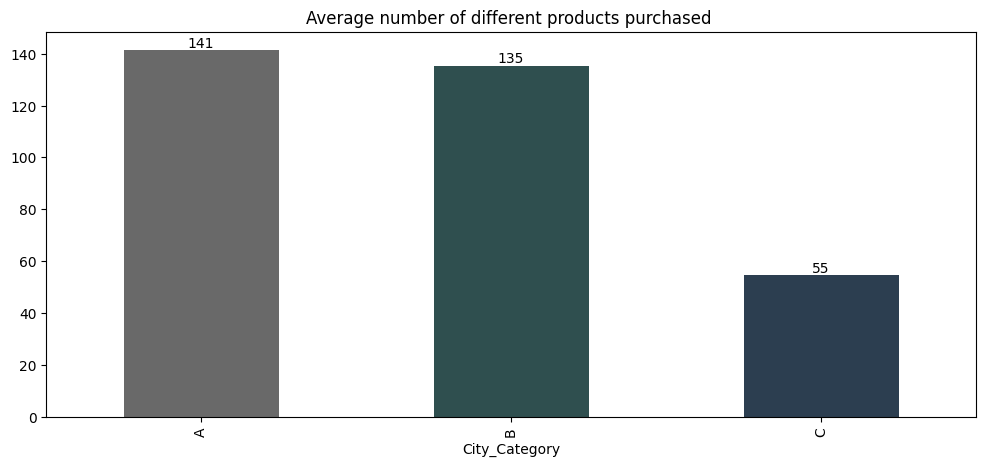

In [ ]:
num_diif_product_per_city_cat =  df.groupby(['City_Category','User_ID'])['Product_ID'].nunique().reset_index(
                            ).groupby('City_Category')['Product_ID'].mean().sort_values(ascending = False)

fig,ax =plt.subplots(figsize = (12,5))
num_diif_product_per_city_cat.plot(kind = 'bar', color = c, ax =ax)
ax.bar_label(ax.containers[0],fmt='%.0f')
ax.set_title('Average number of different products purchased ')
plt.show()

* Average number of unique products per user is also least in City Category C.  
  however,City Category B with almost equal number unique products per user  
   as City Category A, has significantly greater Average per transaction.

**Q. What is the reason behind Average per transaction of City Category B is  
   greater than A ? since, its average number unique products purchased per  
     customer is not different from A.**

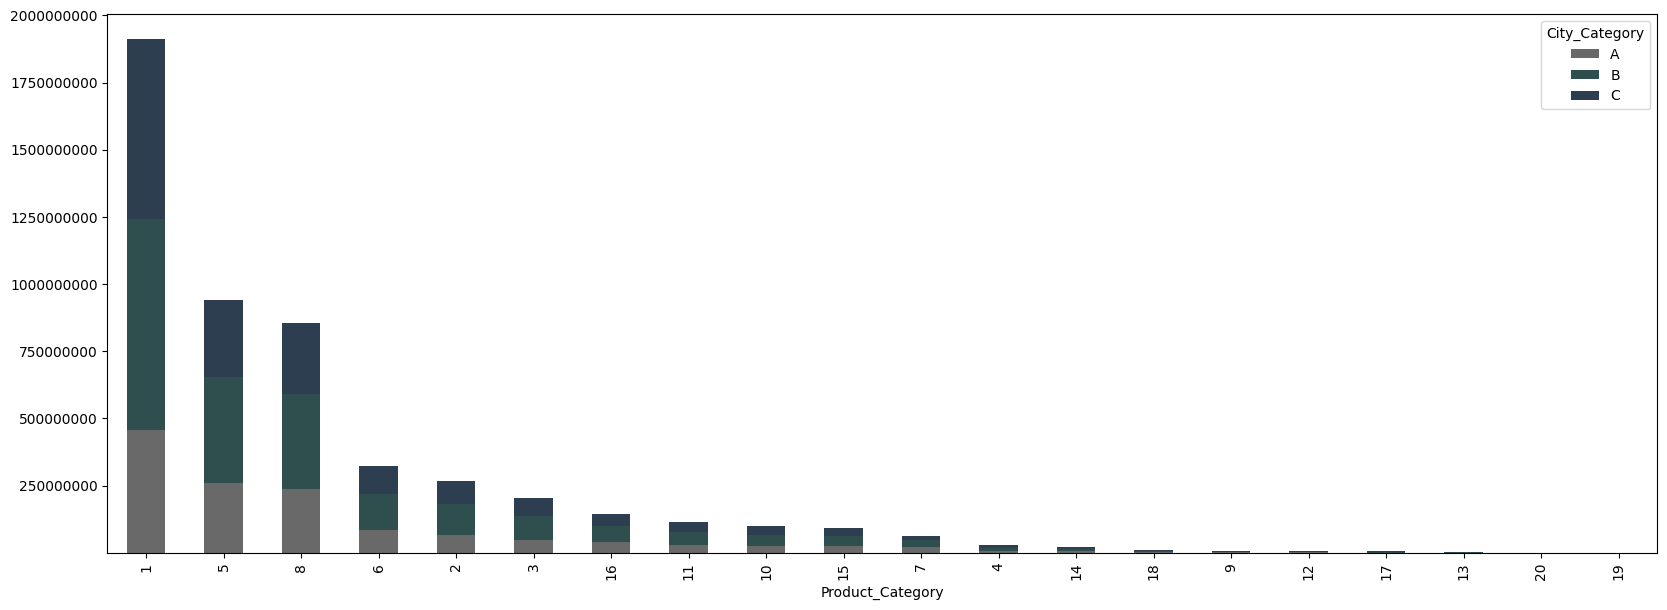

In [ ]:
#Checking Purchasing pattern
city_purchasing_pattern= df.groupby(['Product_Category','City_Category'])['Purchase'].sum(
                          ).unstack().sort_values(by = ['A','B','C'],ascending = False)

fig,ax =plt.subplots(figsize =(20,7))
city_purchasing_pattern.plot(kind = 'bar', stacked =True,color = c,ax =ax)
ax.ticklabel_format(style ='plain',axis ='y')
plt.show()

* There is no difference in purchasing pattern. similar to gender top3 most  
preferred product categories in each city category are 1,5,8.

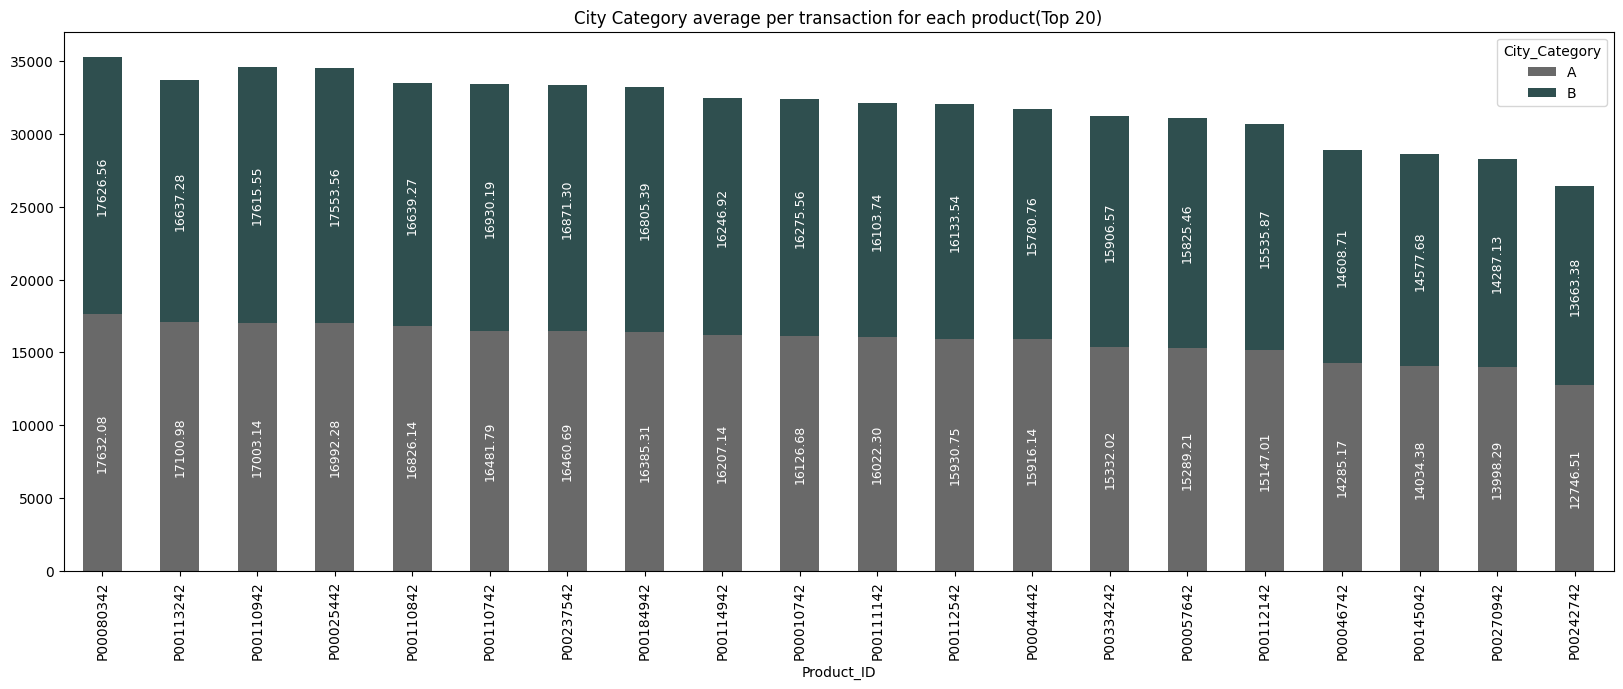

In [ ]:
# using top_20_products and top_3_product_df created earlier
city_cat_spending = top_3_pc_df[(top_3_pc_df.Product_ID.isin(top_20_products))& (top_3_pc_df['City_Category'].isin(['A','B']))].groupby(
                   ['Product_ID','City_Category'])['Purchase'].mean().unstack().sort_values(by = ['A','B'], ascending = False)

fig,ax =plt.subplots(figsize =(20,7))
city_cat_spending.plot(kind = 'bar', stacked =True,color = c,ax =ax)
ax.ticklabel_format(style ='plain',axis ='y')
ax.set_title('City Category average per transaction for each product(Top 20)')
for i in ax.containers:
  ax.bar_label(i, fmt = '%.2f',label_type='center', fontsize=9,rotation=90,color = 'white')

plt.show()

* Average per transaction on  different products in both the city Categories  
are very close to each other, there is not much difference, based on top20  
   products.

* Customers from City Category B is spending as par as A on each product,  
  indicates that they are purchasing around equal quantity of same products as A.


**Conclusion:**
* There might be some expensive products other than top20 product   
that customers from city category B have purchased, which is difficult  
 to  determine without a price column. However, we can assume that  
  customers from city categoty B are less price sensetive than A.


# Stay in the current city years column.

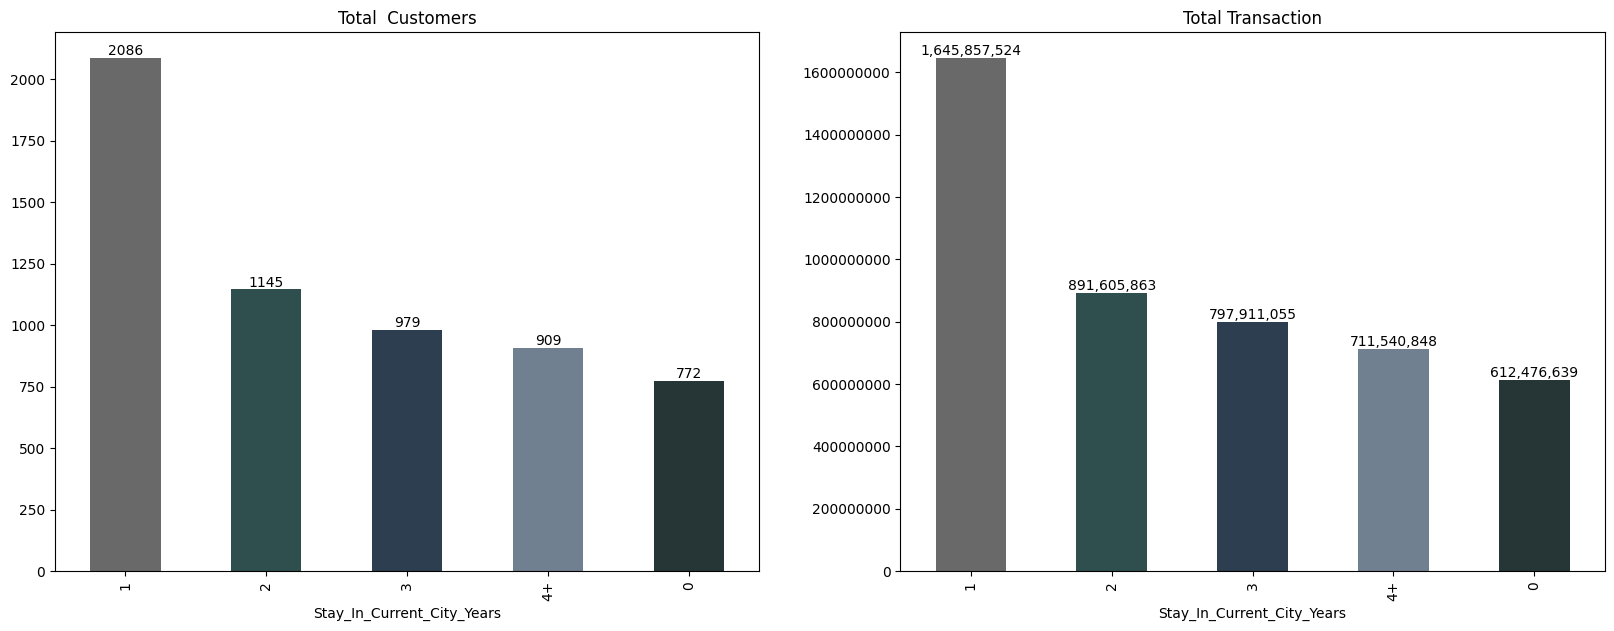

In [ ]:
total_cust_liv_in_city_yrs = grouped_df['Stay_In_Current_City_Years'].value_counts()
total_tran_liv_in_city_yrs = grouped_df.groupby('Stay_In_Current_City_Years')['Purchase'].sum().sort_values(ascending = False)

fig, ax =plt.subplots(1,2,figsize=(20,7))
total_cust_liv_in_city_yrs.plot(kind = 'bar', color = c, ax = ax[0])
ax[0].set_title('Total  Customers')
ax[0].bar_label(ax[0].containers[0])

total_tran_liv_in_city_yrs.plot(kind = 'bar', color = c, ax = ax[1])
ax[1].set_title('Total Transaction')
ax[1].ticklabel_format(style = 'plain', axis = 'y')
ax[1].bar_label(ax[1].containers[0],fmt = '{:,.0f}')

plt.show()

* Majotity of customers living in their current for 1 years, this number  
 gradually decreases with the increase in year.

* Customer living in the city from 0 years are lowest in number. it is  
 understandable because new customers areless aware about stores  
  and sales.

**Potential Reason:**
1. Residents are changing their city after living for 1 year, therefore,  
 the population of customers living in their current city for more than   
 1 year is less.
2. Customers living in the current city for more than 1 year are more aware  
 about other locations and stores in the city, and they are shopping from  
 there. they are might getting better offers from other compititers.



> In context of walmart, reason 2 is relevent and decision should be made based on it.




**Q. With the number of years in the city increases total transaction  
 gradually decreases, check is this pattern is similar in all the city  
  category.**


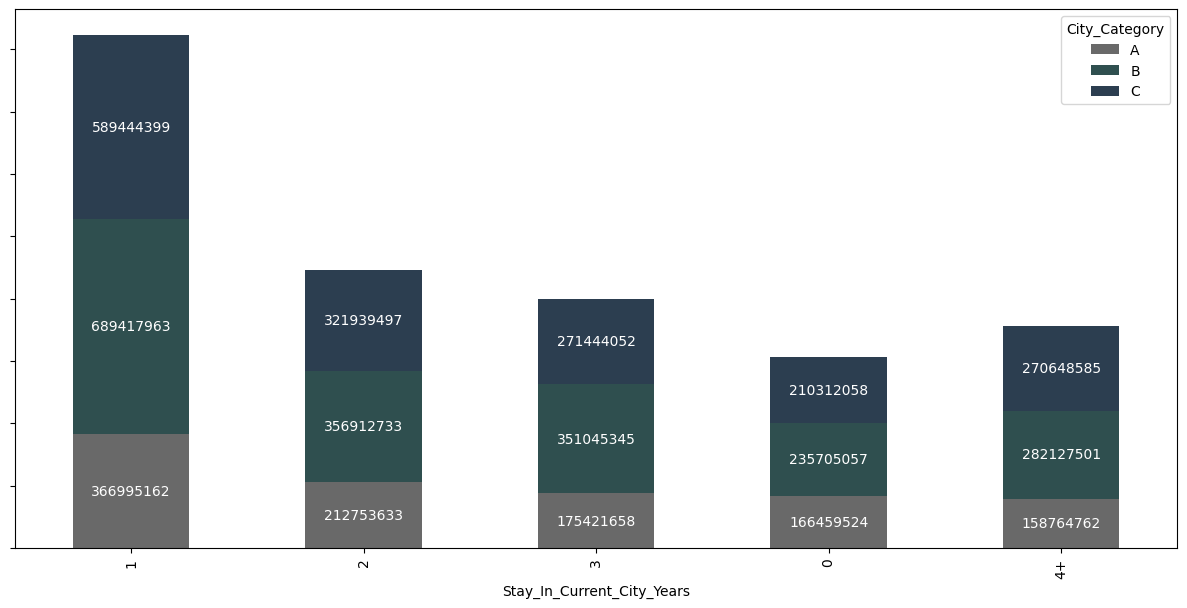

In [ ]:
grp_data = grouped_df.groupby(['Stay_In_Current_City_Years','City_Category'])['Purchase'].sum(
            ).unstack().sort_values(by =['A','B','C'], ascending =  False)

fig,ax = plt.subplots(figsize =(15,7))
grp_data.plot(kind = 'bar', stacked = True, color = c, ax =ax)
ax.ticklabel_format(style ='plain', axis ='y')
ax.set_yticklabels([])
for i in ax.containers:
  ax.bar_label(i, fmt = '%.0f',label_type='center', color ='white')
plt.show()

* In all city categories total transaction is decresing gradually with increase in year.

# Product Category column

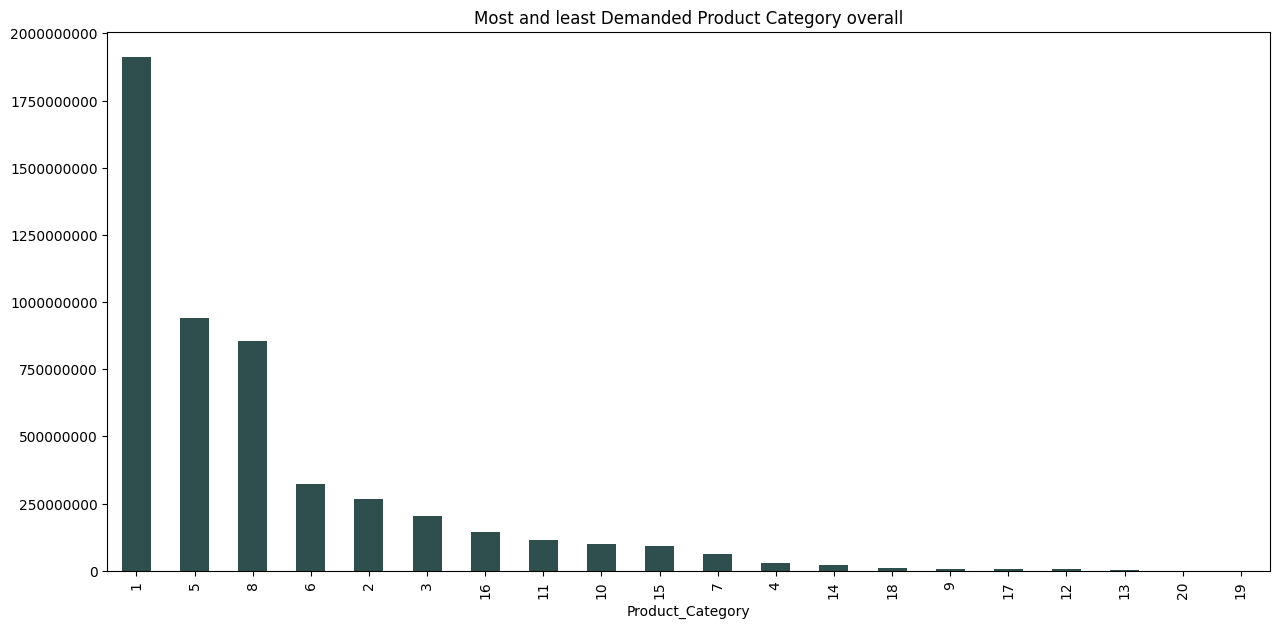

In [ ]:
# Most demanded and least demanded product category

dta= df.groupby('Product_Category')['Purchase'].sum().sort_values(ascending = False)
dta.plot(kind ='bar', color ='darkslategray', figsize =(15,7))
plt.title('Most and least Demanded Product Category overall')
plt.ticklabel_format(style = 'plain', axis = 'y')

plt.show()


* product category 1 is most demanded category followed by 5 and 8,   
but the difference between 1 and others is huge.

* products from 18,9,17,12,13,20 and 19 has very low demand.

# Occupation

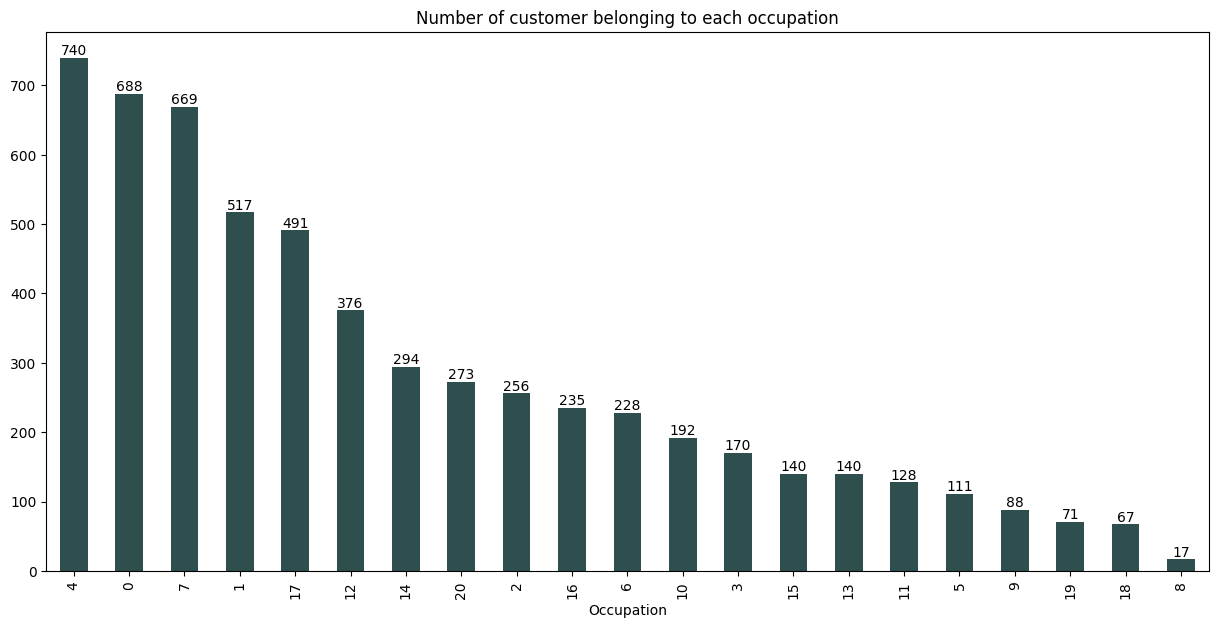

In [ ]:
Cus_dist_per_occ = grouped_df.Occupation.value_counts()

fig,ax = plt.subplots(figsize =(15,7))
Cus_dist_per_occ.plot(kind ='bar', color ='darkslategray', ax=ax)
ax.set_title('Number of customer belonging to each occupation')
ax.bar_label(ax.containers[0])
plt.show()

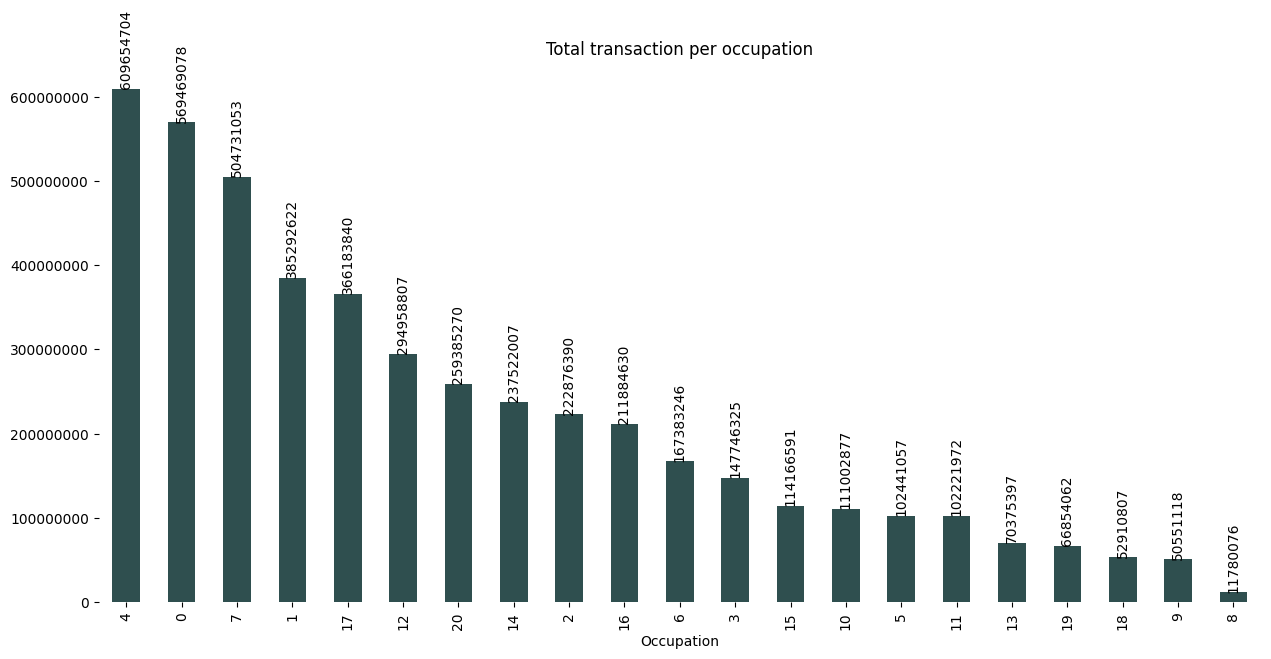

In [ ]:
tot_tran_per_occ = grouped_df.groupby('Occupation')['Purchase'].sum().sort_values(ascending = False)

fig,ax = plt.subplots(figsize =(15,7))
tot_tran_per_occ.plot(kind ='bar', color ='darkslategray',ax=ax)
ax.ticklabel_format(style = 'plain', axis ='y')
ax.set_title('Total transaction per occupation')
ax.bar_label(ax.containers[0],fmt ='%.0f',rotation=90)
for spine in ax.spines.values():
  spine.set_visible(False)
plt.show()

* Customers from Occupation 4,0,7 are spending most,and majority of customers are from these occupations.

# Important segments.

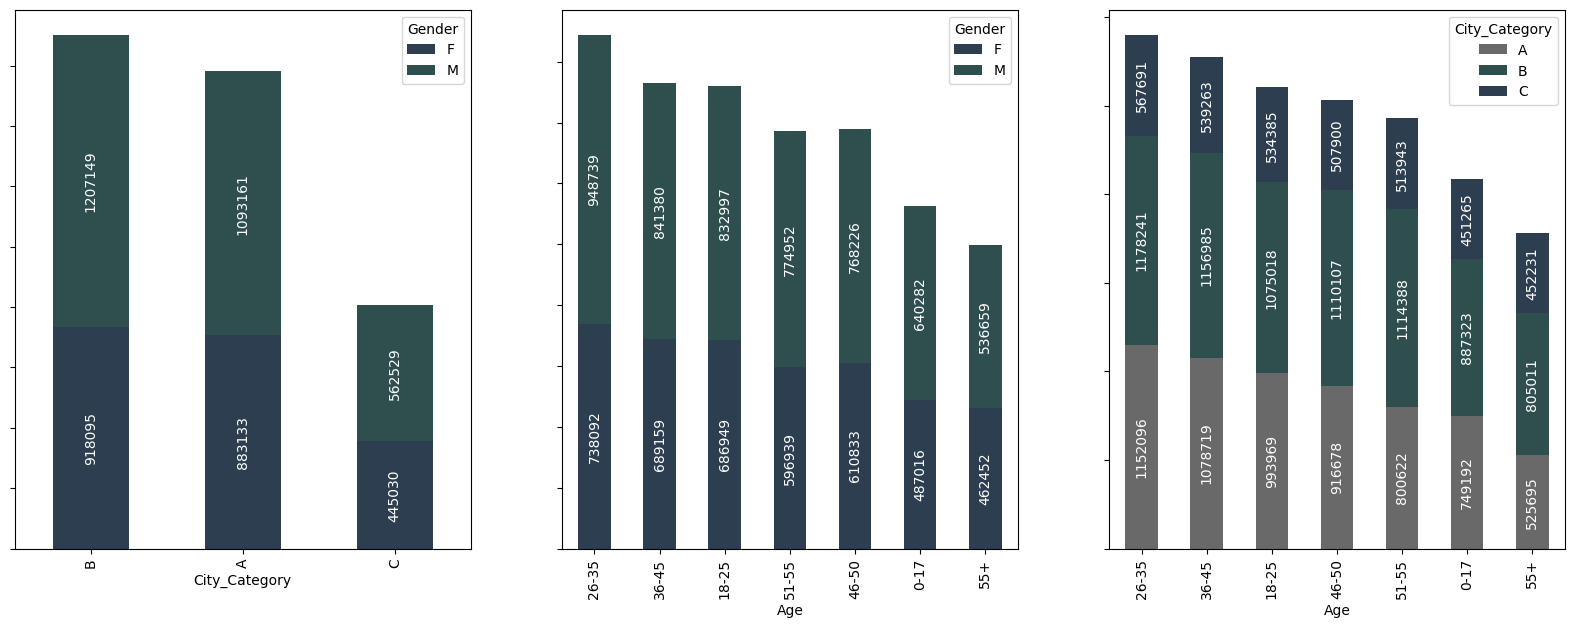

In [ ]:
gender_city_category = grouped_df.groupby(['City_Category','Gender'])['Purchase'].mean().unstack().sort_values(by =['M','F'],ascending = False)
gender_age = grouped_df.groupby(['Age','Gender'])['Purchase'].mean().unstack().sort_values(by =['M','F'],ascending = False)
age_city_category = Gender_city_Category = grouped_df.groupby(['Age','City_Category'])['Purchase'].mean().unstack().sort_values(by =['A','B','C'],ascending = False)


fig,ax =plt.subplots(1,3,figsize = (20,7))

gender_city_category.plot(kind = 'bar', stacked = True, color = color, ax =ax[0])
ax[0].set_yticklabels([])
for i in ax[0].containers:
  ax[0].bar_label(i, fmt = '%.0f',label_type='center', color ='white',rotation =90)

gender_age.plot(kind = 'bar', stacked = True, color = color, ax =ax[1],)
ax[1].set_yticklabels([])
for i in ax[1].containers:
  ax[1].bar_label(i, fmt = '%.0f',label_type='center', color ='white',rotation =90)

age_city_category.plot(kind = 'bar', stacked = True, color = c, ax =ax[2])
ax[2].set_yticklabels([])
for i in ax[2].containers:
  ax[2].bar_label(i, fmt = '%.0f',label_type='center', color ='white',rotation =90)
plt.show()

# Insights:
## **📊 Executive Summary & Key Takeaways**
* **The Revenue Engine:** Total revenue is primarily driven by **Customer Volume  
(Distribution)** across Age and Marital Status, but in City Categories, **Average  
 Transaction Value (ATV)** is the real differentiator.

* **The Hero Categories:** Product Categories **1, 5, and 8** are the business's backbone,   
driving **73% of overall revenue** across almost all customer segments.

* **The Ideal Profile:** High-value revenue is heavily anchored toward **Male customers**,  
 individuals **aged 26–35**, and residents of **City Category B**.




## **👥 Customer Demographics**

###**1. Gender Dynamics**
* **Revenue Dominance:** Male customers account for **77% of total  transaction   
  revenue**,driven by a larger customer base and a significantly higher volume  
  of products purchased per transaction.

* **Shared Preferences:** Despite differences in overall spending volume, purchasing  
 patterns are identical: both genders allocate roughly **70% of their spend** to  
  Product Categories 1, 5, and 8.

### **2. Age Distribution & Spending Hierarchy**
* **The Sweet Spot (26–35):** The 26–35 age cohort forms the majority of the   
  customer base and generates the highest total transaction volume.
* **ATV Hierarchy:** Average transaction value follows a distinct age-based lifecycle:$$\text{26–35} > (\text{18–25}, \text{36–45}) > (\text{46–50}, \text{51–55}) > \text{55+} > \text{0–17}$$
* **Behavioral Clustered Habits:** Purchasing behaviors are highly aligned between  
 specific age groups: (18–25 $\approx$ 36–45) and (46–50 $\approx$ 51–55).

### **3. Marital Status & City Tenure**
* **Marital Status:** **Unmarried customers** make up the majority of the database. Their   
transaction share perfectly mirrors their population size, with no notable variance in  
 purchase behavior or ATV compared to married customers.

* **City Tenure Churn:** Customers in their **1st year of city residency** are the   highest  
revenue contributors. Customer density steadily declines for every subsequent year  
of residency.

### **4 City Category Analysis**
* **City  Category B (High Value / Premium):** The highest revenue contributor, driven by  
 a superior ATV. Customers here purchase high volumes and are notably **less price-sensitive**.

* **City Category A (High Volume / Balanced):** Matches City B in terms of product   
quantities purchased, but has lower average transaction values (higher price sensitivity).

* **City  Category C (Mass Market / Low Yield):** Despite having the highest number of   
total customers, City C contributes the least to overall transactions due to exceptionally  
 low purchase quantities.


## **🎯 Strategic Customer Segmentation**
Segments are defined by Average Transaction Value (ATV) thresholds derived from multivariate  
 analysis.

### **1. High-Value Segment ($>\text{ATV } 1,000,000$)**

**Strategic Focus:** Retention and premium upselling.
* Males in City Categories A & B
* City Category B residents aged 18–25, 26–35, 36–45, 46–50, and 51–55
* City Category A residents aged 26–35 and 36–45


### **2. High-Mid Value Segment ($\text{ATV } 800,001 - 1,000,000$)**

**Strategic Focus:** Cross-selling Core Categories (1, 5, 8).
* Females in City Categories A & B

* City Category B residents aged 0–17 and 55+

* City Category A residents aged 18–25, 46–50, and 51–55

* Males aged 18–25, 26–35, and 36–45

### **3. Low-Mid Value Segment ($\text{ATV } 600,000 - 800,000$)**

**Strategic Focus:** Volume-driving promotions
* City Category A residents aged 0–17

* Males aged 0–17, 46–50, and 51–55

* Females aged 18–25, 26–35, 36–45, and 46–50

### **4. Low-Value Segment ($<\text{ATV } 600,000$)**

** Strategic Focus:** Low-cost digital engagement or basket-building incentives.

* All customers (regardless of Gender or Age) living in City Category C

* City Category  A residents aged 55+

* Females aged 0–17, 51–55, and 55+

* Males aged 55+


## **📌 Key Strategic Note:**
 * City Category B is an absolute powerhouse. Every single customer demographic  
  (regardless  of age or gender) residing in City B falls strictly into either the High-  
  Mid or High-Value segment, proving it to be your most lucrative market.


# Recommendations:
**📈 1. High-Yield Customer Acquisition Strategies**
* Target Premium Demographics, Prioritize acquisition campaigns targeting  
  Male customers in City Categories A and B.
* Establish B2B2C affiliate programs with corporate offices, since the major   
  working class, 26–45 age cohort represents the highest-spending Customers.
* Allocate the primary share of the general marketing budget to City Category B  
 Since, it is a common sub-segment in all the high or high-mid value segments.

**🚀 2. Customer Lifetime Value (LTV) & Youth Awareness**

* Capture the Next Generation (Ages 0–17),Secure early brand loyalty by   
  aggressively targeting the under-18 demographic.

* Formulate Traditional & Digital Stretegy. Run targeted ads on kid-focused   
television networks and leverage social media influencers who command  
 a heavy underage following.

**💸 3. Average Order Value (AOV) Optimization**
* Introduce volume-based tier rewards,To counter low transaction values  
  among Females, Seniors(50+).
* Implement structural cart incentives such as, buy 'x' get 'y' free or get  
 'x'% discount on the purchase of 'y' number of quantities.
* Bundle/Package complementary products together at a slight discount to  
  naturally push these specific segments into purchasing higher quantities  
  per transaction.

**💎 4. Premium Retention: High-Value Segment VIP Track**

**Target Customers:** Males in Cities A & B, Age 26–45 in City A,  
                      and Age 18–55 in City B.

* Establish personalized email and SMS workflows to instantly notify them  
  of premium arrivals and exclusive previews.

* Issue high-value, time-sensitive loyalty coupons (e.g., "Valid for the next  
  'x' days only") to compress the time window between their purchases.

**🔄 5. Multi-Year Residency Retention & Loyalty**

* Combat the natural residency churn rate by introducing a structured loyalty   
  points system specifically tracking city tenure. Reward customers who have   
  resided in the city for 1+ years with higher point-multipliers to incentivize  
   frequent in-store visits.

* Enhance end-to-end customer service (both floor assistance during shopping and   
 post-purchase resolution). Superior service is the lowest-cost,highest-return  
  mechanism to retain long-term city residents.

**🧲 6. Customer Retention Stretegy**
* Extend highly targeted post-Black Friday promotional windows with strategic,  
   short-term discounts on top-selling Product categories for high value segments.
   
* Closely monitor local competitor pricing and matching structures. Deploy aggressive,  
 localized promotional counter-offers during major regional festivals and peak retail   
 holiday sales.





